# Assessment 1: Anthropogenic pollutants across diverse land covers
<a name="top"></a>

❗️ **Deadline: 2pm, Friday 6th December 2024**
<br>
❗️ **Please Submit your notebook as a PDF. For instructions, see the end of this notebook**

This is the first piece of assessed coursework for GEOG5302 Data Science for Practical Applications. It's worth 30% of the module credit. For this assignment, you'll be putting all the skills you've learnt in lectures and computer labs so far into practice. You'll find Labs 1-8 should be helpful in identifying the code and processes you'll need for each step. We start by loading in data, doing some wrangling
and visual investigation, before analysing the data using clustering, classification, regression, and some spatial tools.

Some of the steps in this notebook are simple stages in preparation/loading needed to complete the larger tasks. Items which are assigned marks will be clearly numbered and highlighted __in bold__, with the number of marks specified in (_italics and brackets_) after the question. To receive the marks, you must clearly type out your answer to demonstrate your understanding- just printing out the answer isn't sufficient.

You'll be working with a custom dataset containing dominant land cover and mean values of Nitrogen Oxides (NOx), Nitrogen Dioxide (NO₂), and Sulfur Dioxide (SO₂) (`Land_Cover_and_Pollution_Dataset_2017_2023.csv`) for each Local Administrative Unit (LAU2) in England and Wales (`LAU2_Dec_2014_FCB_in_England_and_Wales.shp`). The dataset spans 2017 to 2023 (7 years) and provides insights into spatial pollution patterns over time.


<img src="https://upload.wikimedia.org/wikipedia/commons/a/a4/Air_pollution_by_industrial_chimneys.jpg" alt="Industrial chimneys emitting pollutants" width="500"/>

**Figure 1:** Industrial chimneys emitting pollutants into the atmosphere (*source: [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Air_pollution_by_industrial_chimneys.jpg). License: [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/).*)


## The Problem

Elevated levels of NOX and NO₂ are linked to a variety of societal issues inlcuding serious respiratory health issues, such as asthma and chronic obstructive pulmonary disease (COPD) [(Yorifuji et al., 2019)](#references) and ground-level ozone, which can lead to smog in dense urban areas [(Chang et al., 2019; Liu et al., 2021)](#references). SO₂ emissions are  linked to industrial activities, leading to acid rain formation that adversely affects both terrestrial and aquatic ecosystems [(Yeung et al., 2021)](#references). SO₂ emissions primarily arise from the combustion of fossil fuels and industrial processes. The formation of acid rain due to SO₂ emissions poses significant threats to ecosystems, affecting soil and water quality [(Oxley et al., 2013)](#references). LAU2 units provide a granular spatial resolution that allows for detailed analysis of air pollution patterns and their impacts at local scales. This level of detail is crucial for identifying specific areas that are disproportionately affected by pollutants such as NOx, NO₂, and SO₂, thereby enabling targeted interventions and resource allocation.

_In this assessment we look at NOx, NO₂, and SO₂ at local scales in the context of landcover dominance._





## The Data

### Land Cover
Dominant land cover (e.g., agriculture, built-up areas, etc.) for each LAU2 is derived from the UK Centre for Ecology and Hydrology (CEH) Land Cover Map series ([LCM](https://www.ceh.ac.uk/data/ukceh-land-cover-maps)). The land classes we used are grouped into a simpler classification called the **UK CEH Aggregate Classes**. Understanding the primary land cover type is essential, as it can influence pollution levels and air quality in different ways.

### Atmospheric Pollution
Mean annual measurements for **NOx**, **NO₂**, and **SO₂** have been derived from the UK Government's Department for Environment, Food & Rural Affairs ([DEFRA Modelled Background Pollution Data](https://uk-air.defra.gov.uk/data/modelling-data)). We're looking at these three pollutants to explore spatial patterns and understand their impact on air quality and the environment. Each pollutant reveals a unique perspective on air quality.

- **Nitrogen Oxides (NOx)**: Primarily linked to vehicles, industry, and some agricultural practices. Elevated NOx levels contribute to respiratory health issues, acid rain formation, ground-level ozone, which can harm both ecosystems and human health.

- **Nitrogen Dioxide (NO₂)**: A specific type of NOx often concentrated in urban areas with heavy traffic. Closely tied to vehicle emissions, NO₂ contributes to smog, which is why it's particularly useful to study NO₂ in relation to urban land cover, where pollution may be higher.

- **Sulfur Dioxide (SO₂)**: Produced mainly from burning fossil fuels and certain industrial activities. SO₂ can cause acid rain and respiratory health issues, making it especially relevant in areas near industrial zones.

### Boundaries
The [Local Administrative Units (LAU)](https://ec.europa.eu/eurostat/web/nuts/local-administrative-units) are part of a geographical classification defined by Eurostat to provide a standardised division of territorial units within the EU. Although updated post-Brexit, LAUs remain useful for historical data studies. Specifically, **LAU2** refers to the smallest administrative unit level, covering areas such as parishes, wards, or town boundaries in England and Wales.

> _Note_: LAU2 boundaries are similar to the [Lower Super Output Areas (LSOA)](https://www.ons.gov.uk/methodology/geography/ukgeographies/statisticalgeographies) you've used in labs, though they differ in their specific delineations.

---

*All data and Data Dictionaries can be downloaded from Minerva.*



## Setting Up
This is an independent data analysis task, but we'll provide the overall steps and the questions you need to answer in this notebook. We'll make sure you're set up with all the preliminary modules you'll need, too. <br>

__Note:__ This is just to get you started! You'll need to import more modules for specific techniqies (e.g. linear regression) later on in the task!

In [248]:
!pip install palettable==3.3.0
!pip install descartes==1.1.0
!pip install pysal==2.6.0
!pip install contextily
!pip install geopandas

import pandas as pd
pd.options.mode.chained_assignment = None
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import metrics

pd.options.mode.chained_assignment = None

<br>

## Over to you!
### Load in the data
Load in the pollution `.csv` data, using the call `Land_Cover_and_Pollution_Dataset_2017_2023`.


In [249]:
LandCovPol = pd.read_csv('/content/Land_Cover_and_Pollution_Dataset_2017_2023.csv')

<br>

## Section 1: Describing the Data

Start with some quick investigations to get to know the data.

__(total: 3 marks)__

__Question 1: How many rows and variables are in the data? _(1 mark)___

In [250]:
rows = np.shape(LandCovPol)[0]
print("there are " f"{rows}" " rows in the data.")
variables = np.shape(LandCovPol)[1]
print("there are " f"{variables}" " variables in the data.")


there are 59647 rows in the data.
there are 6 variables in the data.


<u>**Question 1 Answer: </u>There are 59,647 rows in the data and there are 6 variables in the data.**

<br>

__Question 2: What different types of variables are in the data set, and what do the types mean? How many are there of each? _(2 marks)___

In [251]:
print(LandCovPol.dtypes)
LandCovPol.dtypes.value_counts()

lau214cd                object
Year                     int64
Dominant land cover     object
NO2                    float64
NOx                    float64
SO2                    float64
dtype: object


,count
float64,3
object,2
int64,1


<b><u>Question 2 Answer:</u> In the dataset, there are 3 float64 variables (NO2, NOx and SO2), 2 object variables (lau214cd and Dominant land cover) and 1 int64 variable (Year).

float64 means that the values in these variables are numbers that are decimals and the memory of each value can be a maximum of 64 bits.

int64 means that the values in these variables are numbers that are integers and the memory of each value can be a maximum of 64 bits.

Object in this case means that the values in these variables are strings. In general, '.dtype' describes the type of data in an ndarray (each column in this case). Each element in an ndarray has to be the same number of bytes but strings are different numbers of bytes depending on characters the string contains. Thus when this happens like for the dominant land cover column and the lau214cd column, each string is saved to an ndarray in the form of a pointer (like a placeholder) each of which are the same number of bytes. The pointers that replace the strings are considered as an'object' type, thus the code returns the dtype of these columns containing strings as 'object'.   </b>

<br>

## Section 2: Data Wrangling

You'll need to do some data cleaning and preprocessing, to get the data set ready for analysis.

__(total: 13 marks)__

__Question 3: Which columns have NAs, and how many are there in each column? Describe what this means _(2 marks)___

In [252]:
NAs = LandCovPol.isna().sum()
for x,y in NAs.items():
  if y > 0:
    print("The column labelled \"" f"{x}" "\" has " f"{y}" " NAs")


The column labelled "Dominant land cover" has 12 NAs


<b><u>Question 3 Answer:</u> Only one column ('Dominant land cover') has NAs and there are 12 NAs in this column. This means that there are 12 Local Administrative Units for which there is no data available to describe the type of land those LAUs mainly contain.</b>


__Question 4: One way of dealing with missing values is to remove them. Make this change, and explain how this method may affect the results of our analysis _(2 marks)___

In [253]:
LandCovPolnoNAs = LandCovPol.dropna()
len(LandCovPolnoNAs)

59635

<b><u>Question 4 Answer:</u> This will affect the analysis as there are some local areas of the UK which will not be included in the analysis. This means that the analysis might not be generalisable to the areas that were not included in the analysis if those particular areas do not follow the same trends, relationships and patterns that the remaining data follow.

Generally removing whole responses in a dataset if one variable has missing data like in this case could also result in the loss of power in the analysis as the sample size will be smaller. It could also introduce bias into the sample as the data is not representing the entirety of the UK and also there has been a more significant introduction of human decision when deciding which data to remove, thus introducing an increase in the potential of human error to be made.

However in this case, the number of NAs (12) is very small compared to the size of the entire dataset (59647 or 59635 without the NAs), so the loss of power would be negligible.</b>

<br>

__Question 5: Create a box plot with year on the x axis, Mean NO2 on the y axis, and categorised by type of Dominant Land Cover. Explain what you observe: _(3 marks)___

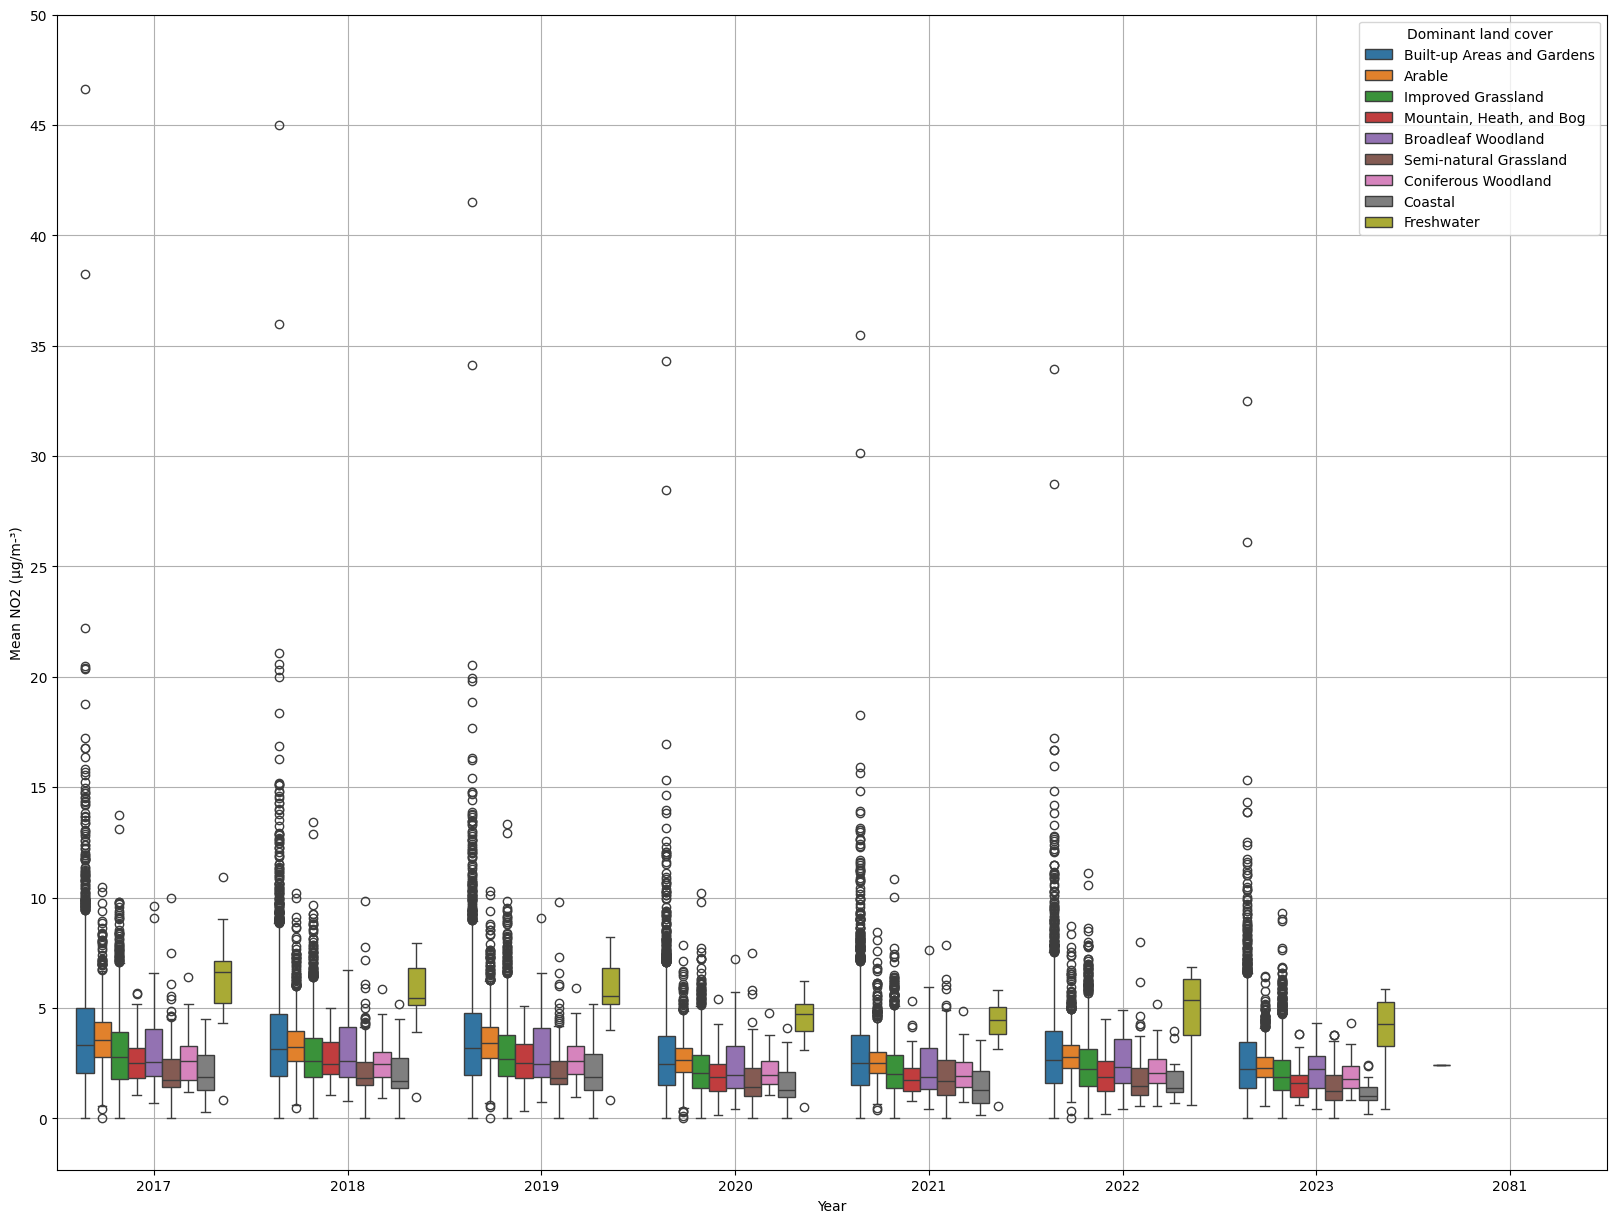

In [254]:
fig, ax = plt.subplots(figsize = (20,15))
sns.boxplot(data = LandCovPolnoNAs, x = "Year", y="NO2", hue = 'Dominant land cover')
plt.ylabel("Mean NO2 (µg/m-³)")
plt.yticks([0,5,10,15,20,25,30,35,40,45,50])
plt.grid()
plt.show()

<b><u>Question 5 Answer:</u> From 2017 to 2023, the range of annual mean NO2 level for 'Built-up areas and gardens' became smaller gradually with the maximum level recorded in an area decreasing (around 46 in 2017 to 33 in 2023) while the minimum level stayed similar throughout the years. There are also many values that are outliers in the data for 'Built up areas and gardens' for every year compared to the other dominant land cover categories. However the median has remained similar in this category over the years at around 3-4 µg/m-³.

The trend for 'freshwater' land is different from other types of land cover over the years. The median has generally been between 4 and 6 µg/m-³ but the distribution of data for 'freshwater' has shifted to lower mean NO2 levels over the years. The maximum and minimum were 11 and 4 µg/m-³ respectively in 2017 but decreased over the years to 6 and 0.5 µg/m-³ respectively in 2023.

The other land types over the years have shown similar trends and spreads of mean NO2 data over the years. Their median NO2 values tend to remain between 1 and 4 µg/m-³ and their interquartile ranges have remained similar sizes to each other within each year. However, over time the interquartile ranges in these land categories have become smaller showing more consistency in the mean NO2 readings. For example, the interquartile range for 'Coastal' land was around 2 µg/m-³ in 2017 but decreased to around 1 µg/m-³ in 2023. Likewise, for 'Broadleaf Woodland', the interquartile ranghe in 2017 was around 3 µg/m-³ but decreased to around 2 µg/m-³ in 2023.FINISH THIS QUESTION</b>

<br>

__Question 6: It looks like something has gone wrong with one of the years. What do you think might have happened? Provide an explanation, and rectify the mistake with the year. Recreate the box plot to demonstrate this has worked _(2 marks)___

<b><u>Question 6 Answer:</u> One of the years displayed on the boxplot's x-axis is 2081 and there is only data for one land category in this year. Upon further examination via the code in the cell below, there is only one row of data in the data frame where the year is 2081. Also for this particular LAU, there is no data in the data frame for the year 2018. This as well as
the fact that the year 2081 has not happened yet suggests that the error may have been caused by human error and that the year 2081
was meant to be 2018 but was entered incorrectly into the data frame.<b>

         lau214cd  Year         Dominant land cover      NO2      NOx      SO2
38445  UKJ2205035  2081  Built-up Areas and Gardens  2.40663  3.17762  0.23458
         lau214cd  Year         Dominant land cover       NO2       NOx  \
38444  UKJ2205035  2017  Built-up Areas and Gardens  2.595232  3.541661   
38445  UKJ2205035  2081  Built-up Areas and Gardens  2.406630  3.177620   
38446  UKJ2205035  2019  Built-up Areas and Gardens  2.407847  3.200309   
38447  UKJ2205035  2020  Built-up Areas and Gardens  1.954951  2.617817   
38448  UKJ2205035  2021  Built-up Areas and Gardens  2.214682  2.895832   
38449  UKJ2205035  2022  Built-up Areas and Gardens  2.122879  2.858509   
38450  UKJ2205035  2023  Built-up Areas and Gardens  1.714596  2.232025   

            SO2  
38444  0.214340  
38445  0.234580  
38446  0.253870  
38447  0.274973  
38448  0.231020  
38449  0.229837  
38450  0.240113  

         lau214cd  Year         Dominant land cover      NO2      NOx      SO2
38445  UKJ2205035

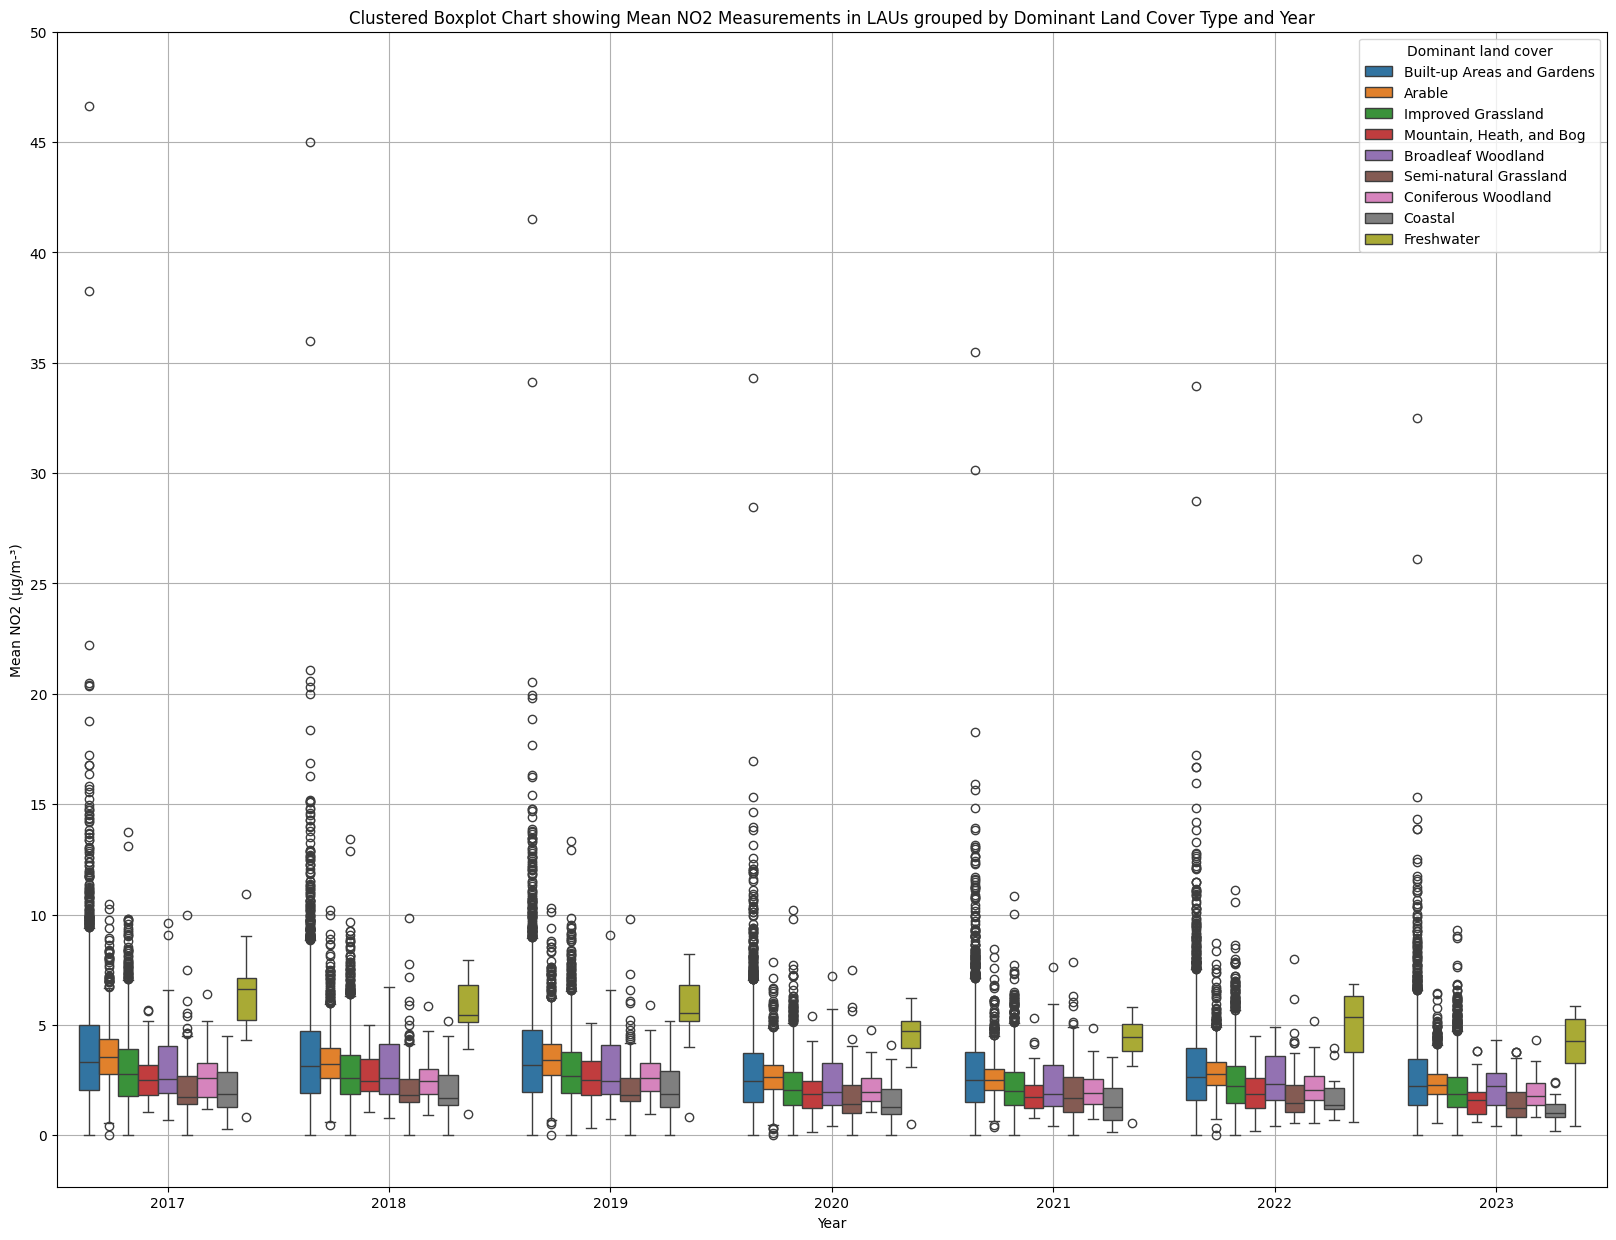

In [255]:
LCPnoNAno2081 = LandCovPolnoNAs
print(LCPnoNAno2081.loc[LCPnoNAno2081['Year'] == 2081])
print(LCPnoNAno2081.loc[LCPnoNAno2081['lau214cd'] == 'UKJ2205035'])
LCPnoNAno2081.loc[LCPnoNAno2081['Year'] == 2081, 'Year'] = 2018
print("\n"f"{LCPnoNAno2081.iloc[[38445]]}")

print("\nNow the year 2081 has been changed to 2018.\nNext the boxplot will be recreated to show the change has been executed.")

fig, ax = plt.subplots(figsize = (20,15))
sns.boxplot(data = LCPnoNAno2081, x = "Year", y="NO2", hue = 'Dominant land cover')
plt.ylabel("Mean NO2 (µg/m-³)")
plt.title('Clustered Boxplot Chart showing Mean NO2 Measurements in LAUs grouped by Dominant Land Cover Type and Year')
plt.yticks([0,5,10,15,20,25,30,35,40,45,50])
plt.grid()
plt.show()


<br>

__Question 7: The final stage of our wrangling requires us to create dummy variables for each of our different land cover types, so they can later be included in regression models. Check the values first, then create a set of dummies, called `Lc_`, followed by the type. Then use `info` to show that this has worked. _(2 marks)___

In [256]:
display(LCPnoNAno2081.value_counts([LCPnoNAno2081['Dominant land cover']]))
dummies = pd.get_dummies(LCPnoNAno2081['Dominant land cover'])
dummies = dummies.add_prefix('Lc_')
LCPnoNAno2081 = pd.concat([LCPnoNAno2081,dummies], axis=1)
LCPnoNAno2081.info()

,count
Dominant land cover,
Built-up Areas and Gardens,28616
Improved Grassland,16182
Arable,11934
Semi-natural Grassland,1384
Broadleaf Woodland,576
"Mountain, Heath, and Bog",391
Coniferous Woodland,270
Coastal,227
Freshwater,55


<class 'pandas.core.frame.DataFrame'>
Index: 59635 entries, 0 to 59646
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   lau214cd                       59635 non-null  object 
 1   Year                           59635 non-null  int64  
 2   Dominant land cover            59635 non-null  object 
 3   NO2                            59635 non-null  float64
 4   NOx                            59635 non-null  float64
 5   SO2                            59635 non-null  float64
 6   Lc_Arable                      59635 non-null  bool   
 7   Lc_Broadleaf Woodland          59635 non-null  bool   
 8   Lc_Built-up Areas and Gardens  59635 non-null  bool   
 9   Lc_Coastal                     59635 non-null  bool   
 10  Lc_Coniferous Woodland         59635 non-null  bool   
 11  Lc_Freshwater                  59635 non-null  bool   
 12  Lc_Improved Grassland          59635 non-null  bool

__Question 8: Finally, create a stacked histogram of the total counts/frequency of `Dominant land cover` using `hue`: _(2 marks)___

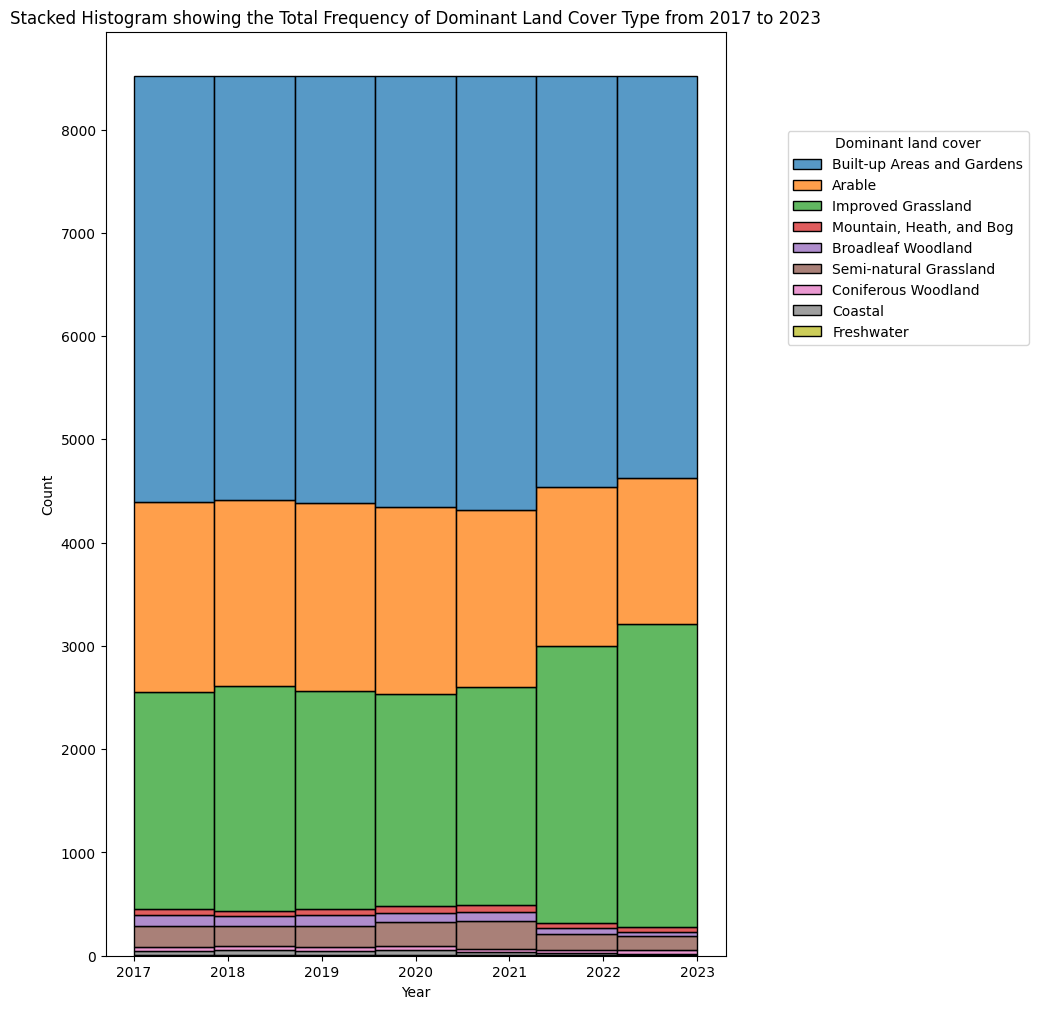

In [257]:
plt.figure(figsize=(8, 12))
ax = sns.histplot(LCPnoNAno2081, x= 'Year', bins = 7, hue = 'Dominant land cover', multiple='stack')
plt.title('Stacked Histogram showing the Total Frequency of Dominant Land Cover Type from 2017 to 2023')
sns.move_legend(ax, "upper right", bbox_to_anchor=(1.5, 0.9))


<br>

## Statistics
You'll now begin to statistically explore the variables and relationships between them.

__(total: 13 marks)__

__Question 9: What is the mean SO₂ measurement in 2018 (round your answer to 2 decimal places)? _(1 mark)___

In [258]:
SO2_2018 = LCPnoNAno2081[LCPnoNAno2081['Year'] == 2018]
SO2_2018['SO2'].mean().round(2)

0.38

<b><u>Question 9 Answer: </u>The mean SO2 measurement in 2018 is 0.38 µg/m-³ (rounded to 2 decimal places).</b>

<br>

__Hypothesis Testing__
Before we start building predictive models, we're going to use hypothesis testing to examine the relationship between a couple of variables of interest. We're going to be focussing on the SO₂ levels for different land cover types. Our research question will be: _'is there a relationship between land cover type and levels of SO₂ pollution?'_

__Question 10: We'll start by creating a null hypothesis. Please explain what is meant by a null hypothesis: _(1 mark)___

<b><u>Question 10 Answer:</u> A hypothesis is a statement about the relationship between variables in an experiment. It is a statement to be tested to see whether it is correct using a statistical hypothesis test.

A null hypothesis is a statement made which claims the relationship between the variables being studied does not exist and there is no statistically significant difference, relationship or effect happening between different groups or variables in a population or dataset.</b>

<br>

__Question 11: If we assume our null hypothesis is that "there is no statistically significant difference in average SO₂ emissions between 'Built-up Areas and Gardens', and 'Arable' ", what would our alternative hypothesis be? _(1 mark)___

<b><u>Question 11 Answer:</u> The alternative hypothesis would be:

" There is a statistically significant difference in average SO2 emissions between "Built-up Areas and Gardens" and "Arable".</b>

<br>

__Question 12: To see if there is a difference between groups, we can start by running a t-test to examine the difference between SO₂ emission levels for Built-up Areas and Gardens, and Arable. Run the t-test below, report the value to 2 decimal places, and explain what the results show. Please also justify which type of t-test you have used. _(4 marks)___

In [259]:
from scipy.stats import ttest_ind
from scipy.stats import levene

ttest1 = LCPnoNAno2081[LCPnoNAno2081['Dominant land cover'] == 'Built-up Areas and Gardens']
ttest2 = LCPnoNAno2081[LCPnoNAno2081['Dominant land cover'] == 'Arable']
print(levene(ttest1['SO2'], ttest2['SO2'], center='median')) # variances are not equal between samples
ttest_ind(ttest1['SO2'],ttest2['SO2'], equal_var=False)


LeveneResult(statistic=2261.360643659583, pvalue=0.0)


TtestResult(statistic=15.538497529891792, pvalue=2.8028497484956687e-54, df=37838.311421489016)

<b><u>Question 12 Answer: </u>The t test shows a p value of 2.80e-54 (rounded to 2 decimal places). As this value is less than 0.05, this means that there was a significant difference between the mean SO2 measurement in 'Built-up Areas and Gardens' and 'Arable' areas at the 5% significance level. This means we can reject the null hypothesis and accept the alternative hypothesis with 95% confidence that there is a statistically significant difference between average SO2 emissions in "Built -up Areas and Gardens" and "Arable".

The t-test used in this case was an independent samples t-test. This is because the mean annual SO2 measurements being compared by the t test were from different samples (LAUs) which are not related or dependent on each other ('Built-up Areas and Gardens' and 'Arable'). These were independent as there is no known relationship between the individual data measurements within each sample. There is also no known relationship between the two samples 'Arable' and 'Built-up Areas and Gardens' as a whole either.   

The independent samples t-test was adjusted so that it did not assume equal variances. This is because the Levene's test done prior to running the t-test was significant indicating the samples do not have equal variances so the test needed to be altered so that it did not make that assumption and risk introducing more Type I and Type II errors.</b>

<br>

__Question 13: Going back to our hypotheses, which hypothesis do we accept, and which do we reject? Is there a difference in SO₂ levels between Built-up Areas and Gardens, and Arable? _(1 mark)___

<b><u> Question 13 Answer: </u> We accept the alternative hypothesis, " There is a statistically significant difference in average SO2 emissions between "Built-up Areas and Gardens" and "Arable".

We reject the null hypothesis , "there is no statistically significant difference in average SO₂ emissions between 'Built-up Areas and Gardens', and 'Arable'".

There is a statistically significant difference between the SO2 levels in 'Built-up Areas and Gardens' and 'Arable'. </b>

<br>

__Question 14: Before we start building predictive models, we'll explore the correlations between our key variables of interest. Create a subset (called `pollution_sub`) which includes the columns for area code, year, NOx, NO₂, S0₂, and the land cover dummies. Then create an annotated correlation heat map of this data.__

__a) Which variables have the strongest negative assocation, and what is the value of this? _(1 marks)___

__b) What is the association between Arable, and Improved grassland? _(1 mark)___

*Hint: for the heatmap add the following parameters to make sure you can read the table:* `annot_kws={"size": 8}, fmt=".2f"`

In [260]:
pollution_sub = LCPnoNAno2081.drop('Dominant land cover', axis=1)
pollution_sub

,lau214cd,Year,NO2,NOx,SO2,Lc_Arable,Lc_Broadleaf Woodland,Lc_Built-up Areas and Gardens,Lc_Coastal,Lc_Coniferous Woodland,Lc_Freshwater,Lc_Improved Grassland,"Lc_Mountain, Heath, and Bog",Lc_Semi-natural Grassland
0,UKC1101033,2017,1.236901,1.678430,0.136591,False,False,True,False,False,False,False,False,False
1,UKC1101033,2018,1.239636,1.644822,0.143926,False,False,True,False,False,False,False,False,False
2,UKC1101033,2019,1.222224,1.629161,0.139293,False,False,True,False,False,False,False,False,False
3,UKC1101033,2020,0.935884,1.246932,0.158346,False,False,True,False,False,False,False,False,False
4,UKC1101033,2021,0.928736,1.195320,0.298907,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59642,UKh2314028,2019,0.000000,0.000000,0.000000,False,False,True,False,False,False,False,False,False
59643,UKh2314028,2020,0.000000,0.000000,0.000000,False,False,True,False,False,False,False,False,False
59644,UKh2314028,2021,0.000000,0.000000,0.000000,False,False,True,False,False,False,False,False,False
59645,UKh2314028,2022,0.000000,0.000000,0.000000,False,False,True,False,False,False,False,False,False


<Axes: >

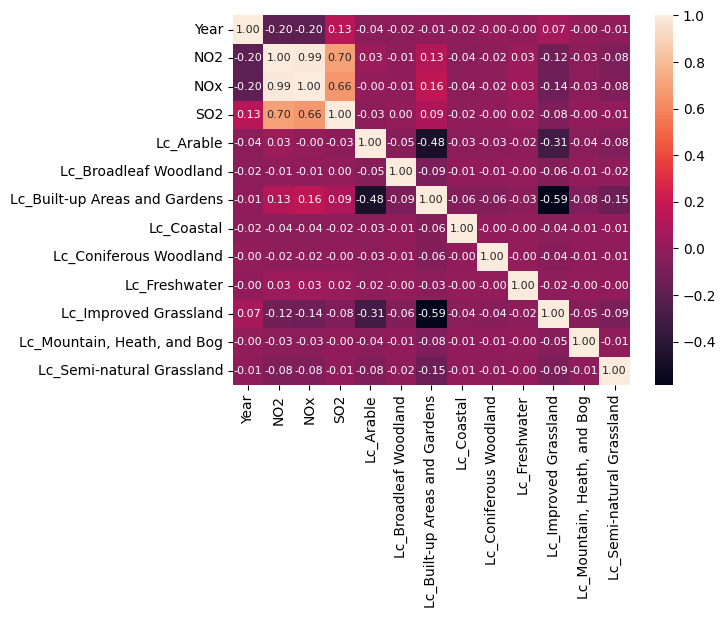

In [261]:
sns.heatmap(pollution_sub.corr(numeric_only=True), annot=True, fmt=".2f", annot_kws={"size": 8})

<b><u> Question 14 Answer: </u>

a) The variables that have the strongest negative correlation are the dummy variables "Lc_Built-up Areas and Gardens" and "Lc_Improved Grassland". They had a correlation coefficient of -0.59.

b) The association between 'Arable' and 'Improved Grassland' is that they are moderately negatively correlated with a correlation coefficient of -0.31.

<br>

__Question 15: Finally, create a scatterplot of mean annual NO2 and SO2 emissions, coloured by dominant land cover type. Comment on what you observe _(3 marks)___

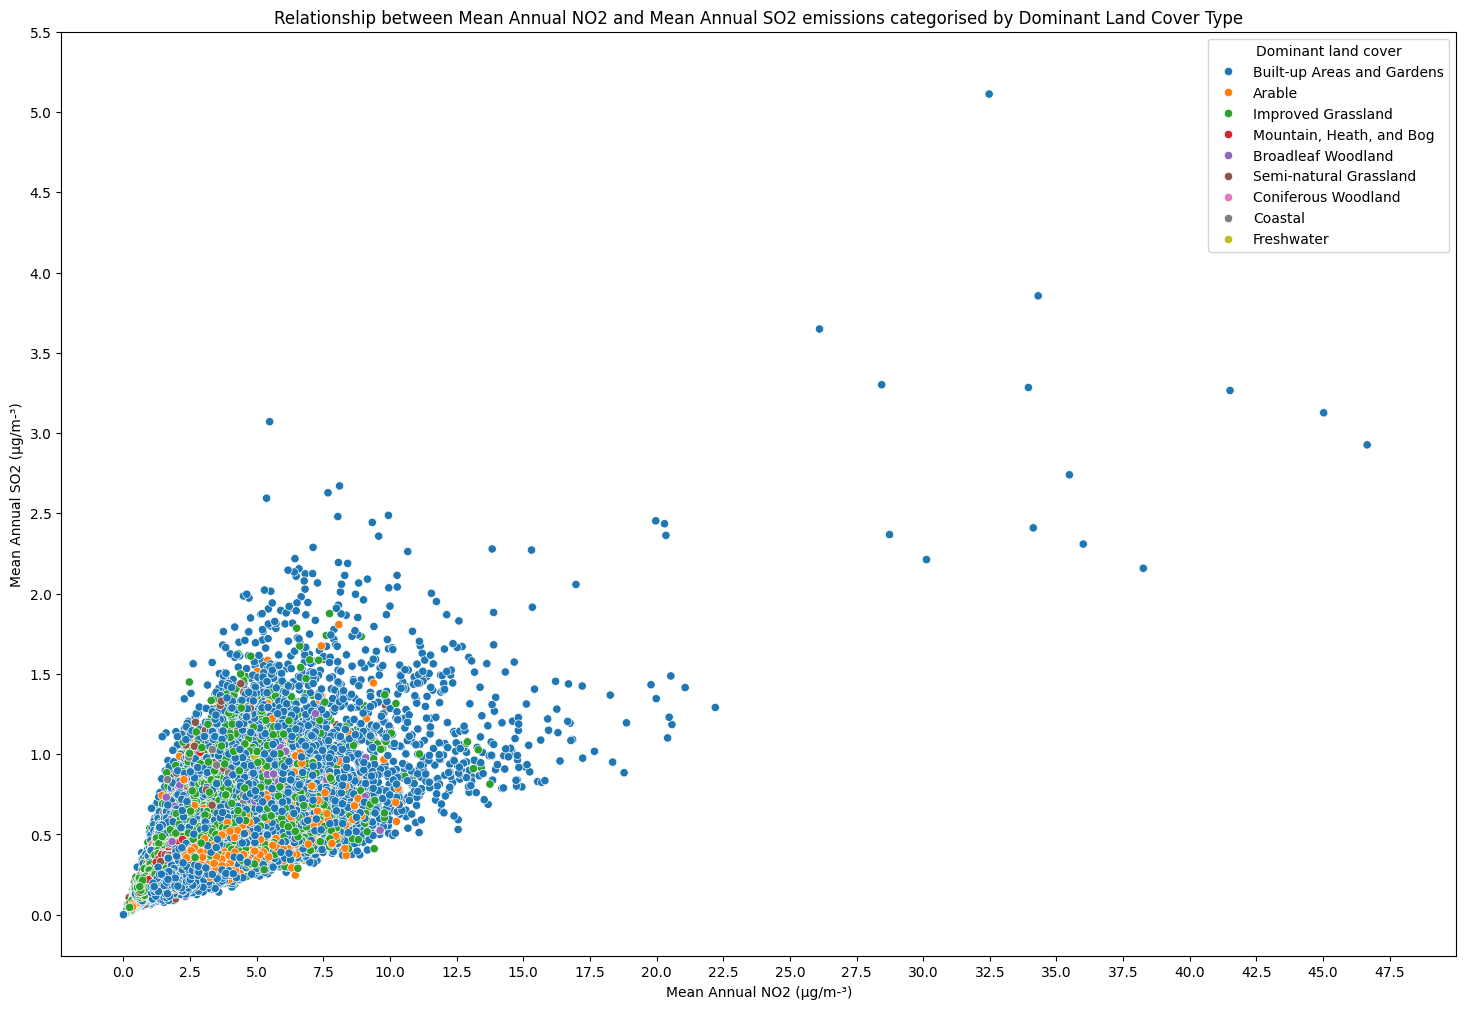

In [262]:
plt.figure(figsize=(18,12))
fig = sns.scatterplot(data = LCPnoNAno2081, x = "NO2", y = "SO2", hue = 'Dominant land cover')
plt.xlabel("Mean Annual NO2 (µg/m-³)")
plt.ylabel("Mean Annual SO2 (µg/m-³)")
xticks = list(np.arange(0,50,2.5))
yticks = list(np.arange(0,6,0.5))
plt.xticks([0,5,10,15,20,25,30,35,40,45,50])
plt.xticks(xticks)
plt.yticks(yticks)
plt.title("Relationship between Mean Annual NO2 and Mean Annual SO2 emissions categorised by Dominant Land Cover Type")
#sns.move_legend(fig, "upper right", bbox_to_anchor=(1.5, 0.9))
plt.show()

<b><u>Question 15 Answer:</u> There is a positive trend generally between the Mean Annual SO2 levels in a given area and the Mean Annual NO2 levels in the same area. This trend is seen across all types of dominant land cover. This means that for all land types, the graph implies that when higher levels of mean annual NO2, mean annual SO2 levels do too. However, due to the large number of points displayed in this scatter plot, it is difficult to ascretain the relationships of some emissions for land covers that cannot be observed easily (all apart from "Arable", "Improved Grassland" and "Built-up Areas and Gardens").

The majority of the land areas have NO2 levels between 0 and 10. Exceptions to this are "Built-up Areas and Gardens" (which ranges from 0 to around 47), "Improved Grassland" (ranging from around 0 to around 13.75).

The majority of land areas have SO2 levels between 0 and 1.5. The exceptions of this observation are "Built-up Areas and Gardens" (ranging from 0 to 5.1), "Arable! (ranging from around 0 to 1.8), and "Improved Grassland" (ranging from around 0 to 1.9).

Dominant land cover types that showed exceptions show higher levels of NO2 and SO2. This means that there is more variation in the amounts of NO2 and SO2 in areas with these dominant land cover types compared to areas with different dominant land cover types. However, from observation of the descriptive statistics previously calculated, the majority of land areas surveyed in the dataset have dominant land covers of "Arable", "Built-up Areas and Gardens", and "Improved Grassland". Therefore these observations that do not fit the general pattern of SO2 and NO2 levels and arent residing in the funnel shaped cloud of points in the scatter plot could be outliers that were identified in earlier boxplots. </b>

For the clustering and classifications sections of our notebook, we'll focus just the top three dominant land covers (Built-up Areas and Gardens', 'Arable', and 'Improved Grassland') and only focus on the year 2020. Create a subset here  with just these variables, called `pollution_2020`.

In [263]:
pollution_2020 = LCPnoNAno2081[(LCPnoNAno2081['Dominant land cover'] == 'Built-up Areas and Gardens')]
arable = LCPnoNAno2081[(LCPnoNAno2081['Dominant land cover'] == 'Arable')]
pollution_2020 = pd.concat([pollution_2020,arable])
grassland = LCPnoNAno2081[(LCPnoNAno2081['Dominant land cover'] == 'Improved Grassland')]
pollution_2020 = pd.concat([pollution_2020,grassland])
pollution_2020 = pollution_2020[(pollution_2020['Year'] == 2020)]

for x in pollution_2020:
  if x.startswith('Lc_') == True:
    pollution_2020 = pollution_2020.drop(x, axis = 1)

In [264]:
pollution_2020

,lau214cd,Year,Dominant land cover,NO2,NOx,SO2
3,UKC1101033,2020,Built-up Areas and Gardens,0.935884,1.246932,0.158346
10,UKC1101034,2020,Built-up Areas and Gardens,0.834387,1.093537,0.137382
17,UKC1101035,2020,Built-up Areas and Gardens,4.242182,5.658277,0.755658
24,UKC1101036,2020,Built-up Areas and Gardens,2.044993,2.749600,0.359211
38,UKC1101038,2020,Built-up Areas and Gardens,3.131021,4.222843,0.728413
...,...,...,...,...,...,...
59440,UKh2313040,2020,Improved Grassland,3.005760,4.050749,0.357142
59447,UKh2313041,2020,Improved Grassland,4.298950,5.897253,0.647905
59454,UKh2313042,2020,Improved Grassland,3.357964,4.525011,0.418397
59475,UKh2313045,2020,Improved Grassland,3.266756,4.395153,0.370509


<br>

## Clustering
You'll now start exploring these relationships in more detail, by clustering your data.

Start with the K-Means method.

(__total: 10 marks__)


First, create a new subset of the data, called `pollution_stats`. This should include just NO2 and SO2 emissions for 2020.

In [265]:
pollution_stats = pollution_2020[['NO2','SO2']]
pollution_stats.head()

,NO2,SO2
3,0.935884,0.158346
10,0.834387,0.137382
17,4.242182,0.755658
24,2.044993,0.359211
38,3.131021,0.728413


<br>

__Question 16: Using your pollution_stats dataset, use the elbow method to find the optimal number of clusters to use. Test for between 1 and 10 clusters, plot your results, and explain your choice of K- with reference to the meaning of the x and y axis. _(4 marks)___

In [266]:
from sklearn.cluster import KMeans
inertia_list = []
K = range(1,10)
for k in K:
    kmeanModel = KMeans(n_clusters=k)
    kmeanModel.fit(pollution_stats)
    inertia_list.append(kmeanModel.inertia_)

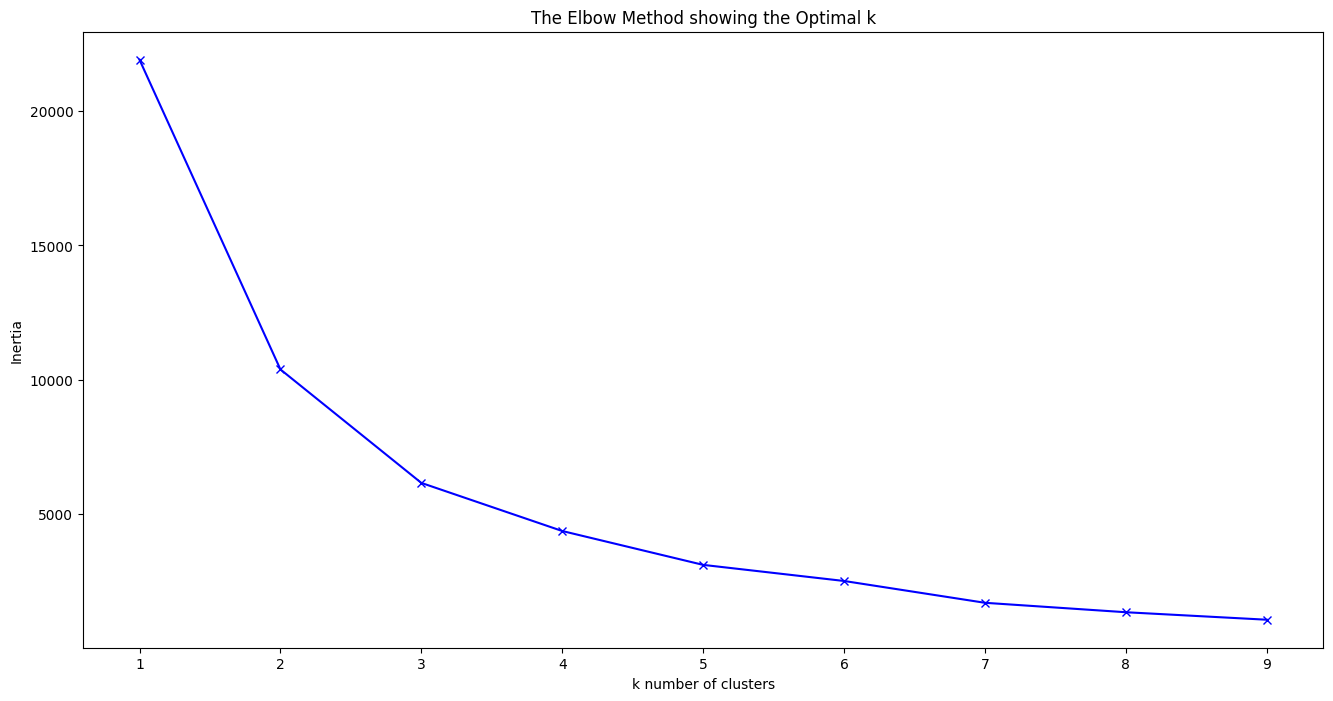

In [267]:
plt.figure(figsize=(16,8))
plt.plot(K, distortions_list, 'bx-')
plt.xlabel('k number of clusters')
plt.ylabel('Inertia')
plt.title('The Elbow Method showing the Optimal k')
plt.show()

<u><b>Question 16 Answer:</u>The code that this graph is based on has calculated a k means model examining the most optimal way to cluster the datapoints(the geographic areas in the UK) based on the NO2 and SO2 measurements found in each area in 2020.The code has calculated a model and the error found in this model 9 times, when the number of clusters has been set at 1,2,3,4,5,6,7,8 and 9 as shown on the x axis. The inertia (the summed squared error(distance) between data points and the centre of their assigned cluster) is shown on the y axis. Thus the data points in this graph show the error level for each model where each model has a different number of clusters.

The aim is to create a parsimonious model that is not overfitting or underfitting the data. This should also be done whilst minimising the amount of error in the model to ensure the model's accuracy at clustering the data. In this case, we can see the error(inertia) decreases as the number of clusters increases. However, to keep the model parsimonious and minimise risk of overfitting the data, we should choose the model that has minimal error and cluster number.

From the graph we can see that the error drops significantly between 1 and 2 clusters, and again between 2 and 3 clusters. However, the error reduction by increasing the number of clusters from 3 to 4 is more minimal. This is also the case for all the decreases in error between clusters after that. Therefore, choosing a model with k=3 clusters is optimal as the error is low and the number of clusters is too but there is also a good balance between the inertia and the amount of clusters.</b>

<br>

__Question 17: Create a K-Means clustering model using your chosen number of clusters. Report the silhouette score (rounded to 3 decimal places), and explain what this means. _(3 marks)___

(__note:__ the silhouette score can take a minute to run- this is quite a big data set!)

In [268]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(pollution_stats)
kmeanslabels = kmeans.labels_
metrics.silhouette_score(pollution_stats,kmeanslabels).round(3)

0.53

<u><b>Question 17 Answer: </u>The silhouette score is 0.531 (rounded to 3 decimal places). Because the silhouette score is positive, this means the data does show clustering when k is set to 3 clusters and shows that the data has been assigned to clusters somewhat correctly according to their labels as the silhouette score is positive. The clustering is moderately strong as the silhouette score is over 0.5 and the maximum it can be is 1.0. This means that on average, the data points in each cluster are closer to the other data points in the same clusters compared to their distance to other clusters that they do not belong to. </b>


<br>

To compare the fit of our model, we could use another clustering method, such as DBSCAN.
This function requires to values for `eps` (epsilon) and `min_samples` to be specified.

__Question 18: Explain how the DBSCAN Algorithm uses these values to calculate clusters _(3 marks)___

<b><u>Question 18 Answer:</u> The epsilon value represents the maximum distance a point can be from a core point to be considered its neighbour. If a point is within the radial distance of the core point defined by the value of epsilon (i.e. distance of point from core point < epsilon value), it is considered a part of the core point's cluster. This is important as this decides which points are in a cluster or not.

A point in the dataset is considered a core point of a cluster if it has a certain number of neighbouring points as defined by the epsilon value radius (i.e. point x is a core point if there are a certain number of points that are less than epsilon distance away from point x). This is because, DBSCAN defines clusters by the number of points per unit area (density of points). The min_samples value is the minimum number of points that should be within in the epsilon radius of a point in order for it to be considered a core point of a cluster. If the given data point is near less than the minimum number of points, it is not considered a core point of the cluster. It is considered a border point of the cluster if at least one point is less than epsilon distance from it. It is considered a noise point (an outlier) if there are no points within epsilon distance of it. </b>

<br>

## Classification

You'll extend what you've learnt from the clustering model, by adding back in Dominant Land Cover, to predict this based on pollutants.

__(total: 16 marks)__

__Question 19: Explain the difference between supervised and _un_ supervised learning methods, and how they are used with different data types _(1 mark)___

<u><b>Question 19 Answer: </u>Supervised learning methods are when data used and inputted into a machine learning model already has labels classifying different categories within the dataset. Supervised learning methods are used to explore the type of relationships each of the classified groups have with each other and associate features of the data to the classification labels that have already been assigned to the data if the methods identify a pattern between data points that all have the same label. This way the model can make predictions about the relationships in new data after being trained on the relationships between the training data in a supervised learning method.

Unsupervised learning methods are when data inputted into a model does not have labels categorising the data within the dataset. Unsupervised learning methods are used to identify patterns and features in the data that may not have been known about before given the data's lack of labels and explore how the data groups itself into different categories based on patterns in the data. Unlike supervised learning, there are no labels of categories in the data already so there are no labels that can be referenced to check whether the groups that the model has split the data into are congruent with other methods of grouping the data. It is a more exploratory method than supervised learning as there is no context to check if the classification that the model decides on is correct. </b>

Go back to your pollution_stats data, and add the original `Dominant land cover` variable back in, but only focusing on the top three dominant land covers (Built-up Areas and Gardens', 'Arable', and 'Improved Grassland').

This should give you a dataset with SO₂, NO₂, Dominant land cover, again for the year 2020, but as we only extract out the three top landcovers, the number or rows is reduced slightly.

In [269]:
pollution_stats = pd.concat([pollution_stats, LCPnoNAno2081['Dominant land cover']], axis = 1)
pollution_stats=pollution_stats.dropna(axis=0,how='any')
pollution_stats

,NO2,SO2,Dominant land cover
3,0.935884,0.158346,Built-up Areas and Gardens
10,0.834387,0.137382,Built-up Areas and Gardens
17,4.242182,0.755658,Built-up Areas and Gardens
24,2.044993,0.359211,Built-up Areas and Gardens
38,3.131021,0.728413,Built-up Areas and Gardens
...,...,...,...
59440,3.005760,0.357142,Improved Grassland
59447,4.298950,0.647905,Improved Grassland
59454,3.357964,0.418397,Improved Grassland
59475,3.266756,0.370509,Improved Grassland


One problem is that sklearn only allows us to classify on numeric data, so we need to convert our three top land cover classes ('Built-up Areas and Gardens', 'Arable', 'Improved Grassland') into integers (0,1,2). To do this, use the `key` method, which can recode categorical data. Assign this to a new variable `Lc_type`:

In [270]:
pollution_stats['Lc_type'] = pollution_stats['Dominant land cover'].map({'Built-up Areas and Gardens': 0, 'Arable': 1, 'Improved Grassland': 2})

In [271]:
pollution_stats

,NO2,SO2,Dominant land cover,Lc_type
3,0.935884,0.158346,Built-up Areas and Gardens,0
10,0.834387,0.137382,Built-up Areas and Gardens,0
17,4.242182,0.755658,Built-up Areas and Gardens,0
24,2.044993,0.359211,Built-up Areas and Gardens,0
38,3.131021,0.728413,Built-up Areas and Gardens,0
...,...,...,...,...
59440,3.005760,0.357142,Improved Grassland,2
59447,4.298950,0.647905,Improved Grassland,2
59454,3.357964,0.418397,Improved Grassland,2
59475,3.266756,0.370509,Improved Grassland,2


Load in the label encoder and encode the labels, using the new `Lc_type` variable.

In [272]:
from sklearn.preprocessing import LabelEncoder
label_encoder_Lc_type = LabelEncoder()
pollution_stats['Lc_type'] = label_encoder_Lc_type.fit_transform(pollution_stats['Lc_type'])

In [273]:
#just looking at the encoded labels not necessary for assessment
LcType_mapping = dict(zip(label_encoder_Lc_type.classes_, label_encoder_Lc_type.transform(label_encoder_Lc_type.classes_)))
print("LcType Mapping:", LcType_mapping)

LcType Mapping: {0: 0, 1: 1, 2: 2}


Now split the data into training and test datasets, using a 75:25 split. Set the random state to 42 (`random_state=42`).

In [274]:
from sklearn.model_selection import train_test_split

In [275]:
#predictor variables subset
predictors = pollution_stats[['NO2', 'SO2']]

In [276]:
predictors_array = predictors.to_numpy()

In [277]:
Lc_type_array = pollution_stats['Lc_type'].to_numpy()
type(Lc_type_array)

numpy.ndarray

In [278]:
train_data, test_data, train_lab, test_lab = train_test_split(predictors_array, Lc_type_array, random_state=42)

<br>

__Question 20: How many instances are in the testing and training sets? Explain how these are used to create a classification model _(3 marks)___

In [279]:
print(len(train_lab),len(train_data),len(test_lab),len(test_data))

6030 6030 2011 2011


<b><u>Question 20 Answer:</u> There are 6030 instances in the training set and there are 2011 instances in the testing set. The training set instances are used by the classification algorithm to learn how the relationship of the NO2 and SO2 levels vary and if this relationship is congruent with the label they are already associated with (the dominant land type covering that area). This analysis of the training data that the model does will teach it to predict the dominant type of land covering an area based on the NO2 and SO2 levels measured in that area.

After it has learnt how to do this based on the training data, the model will then use the algorithm it has created from the learning it has done to predict the dominant land type covering an area. It will do this when given the mean annual NO2 and SO2 levels measured in that area in 2020 by using the information it learned about the data patterns based on the training dataset. It will see if it can correctly classify the data in the test set into categories of different dominant land cover types based on the NO2 and SO2 levels for those places.</b>

Now you're going to build two types of models: a decision tree, and a K-Nearest Neighbours, and then compare the results to find the best fit.

First build a decision tree, set the random state to 42 (`random_state=42`), and fit it to the data.

In [280]:
from sklearn.tree import DecisionTreeClassifier

In [281]:
tree = DecisionTreeClassifier()
tree.fit(train_data,train_lab)

DecisionTreeClassifier()

In [282]:
predictions = tree.predict(test_data)

In [283]:
DT_domlandcovpred = pd.DataFrame(list(predictions))

In [284]:
tree.score(test_data,test_lab)

0.4748881153654898

In [285]:
DT_domlandcovpred['DomLandCov'] = pd.DataFrame(list(test_lab))

In [286]:
DT_domlandcovpred.rename(columns={0:'predicteddomlandcov'}, inplace=True)

In [287]:
DT_domlandcovpred

,predicteddomlandcov,DomLandCov
0,1,0
1,1,0
2,0,0
3,0,2
4,2,0
...,...,...
2006,0,2
2007,0,0
2008,2,2
2009,1,0


<br>

__Question 21:__ <br>
__a) How does the model score? (to 3 decimal places) _(1 mark)___ <br>
__b) What is the model weighted average Precision and Recall? _(2 marks)___ <br>

In [288]:
print(metrics.classification_report(test_lab, predictions, zero_division = 0))

              precision    recall  f1-score   support

           0       0.60      0.59      0.60      1043
           1       0.40      0.38      0.39       478
           2       0.29      0.32      0.31       490

    accuracy                           0.47      2011
   macro avg       0.43      0.43      0.43      2011
weighted avg       0.48      0.47      0.48      2011



<b><u>Question 21 Answer:</u>

a) The model has a score of 0.483 (rounded to 3 decimal places)

b) The weighted average Precision is 0.49 and the weighted average Recall is 0.48. </b>

__Question 22: Now plot the confusion matrix. Comment on what you observe? _(2 marks)___

In [289]:
from sklearn import metrics
confusion_matrix = metrics.confusion_matrix(test_lab, predictions)

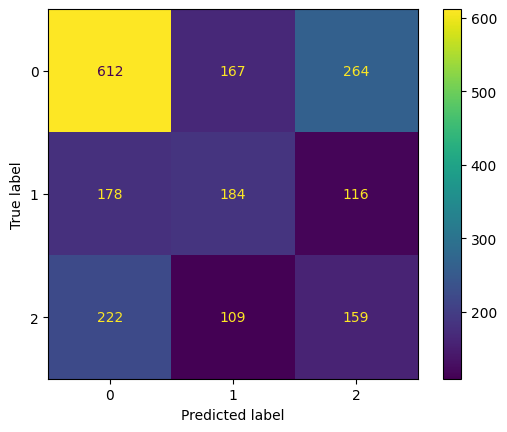

In [290]:
cm1 = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix,display_labels= [0,1,2])
cm1.plot()

<b><u>Question 22 Answer:</u>The confusion matrix shows that for over 624 observations, the decision tree correctly classified areas that had dominant land cover of 'Built-up Areas and Gardens' as 'Built-up Areas and Gardens' based on the levels of NO2 and SO2 observed in those areas that were inputted from the testing data. 163 observations were incorrectly labelled as 'Arable' and 256 were labelled as 'Improved Grassland'.

For 'Arable', 185 areas were identified correctly as 'Arable' based on their observed NO2 and SO2 levels in the testing data. 181 were incorrectly classifed as 'Built-up Areas and Gardens' and 112 were incorrectly classified as 'Improved Grassland'.

For 'Improved Grassland', 162 observations were correctly labeled as 'Improved Grassland' based on the NO2 and SO2 levels in the testing data. 225 observations were incorrectly classified as 'Built-up Areas and Gardens' and 103 were incorrectly classified as 'Arable'.

The algorithm seems to have been better at predicting which areas were covered in 'Built-up Areas and Gardens' land compared to predicting 'Arable' or 'Improved Grassland'.

</u>

You can now compare the results of the decision tree to a K-nearest neighbour classifier. Use the nearest 20 neighbours to build the model. <br>

__Question 23:__ <br>
__a) How does the model score? (to 3 decimal places) _(1 mark)___ <br>
__b) What is the model weighted average Precision and Recall? _(2 marks)___ <br>

In [291]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(train_data, train_lab)

KNeighborsClassifier(n_neighbors=20)

In [292]:
knn.score(test_data, test_lab)

0.546494281452014

In [293]:
predictionsKNN = knn.predict(test_data)

In [294]:
DLCPKNN = pd.DataFrame(list(predictionsKNN))

In [295]:
DLCPKNN['DomLandCov'] = pd.DataFrame(list(test_lab))

In [296]:
DLCPKNN

,0,DomLandCov
0,0,0
1,0,0
2,0,0
3,1,2
4,0,0
...,...,...
2006,0,2
2007,0,0
2008,0,2
2009,1,0


In [297]:
DLCPKNN.rename(columns={0:'Prediction'}, inplace=True)

In [298]:
print(metrics.classification_report(test_lab, predictionsKNN, zero_division = 0))

              precision    recall  f1-score   support

           0       0.58      0.81      0.68      1043
           1       0.52      0.37      0.43       478
           2       0.35      0.15      0.21       490

    accuracy                           0.55      2011
   macro avg       0.48      0.44      0.44      2011
weighted avg       0.51      0.55      0.51      2011



<b><u>Question 23 Answer: </u>

a) The model scores 0.546 (rounded to 3 decimal places)

b) The weighted average for Precision is 0.51 and the weighted average for Recall is 0.55 </b>

<br>

__Question 24: Now plot the confusion matrix. Comment on what you observe? _(2 marks)___

In [299]:
confusion_matrix2 = metrics.confusion_matrix(test_lab, predictionsKNN)

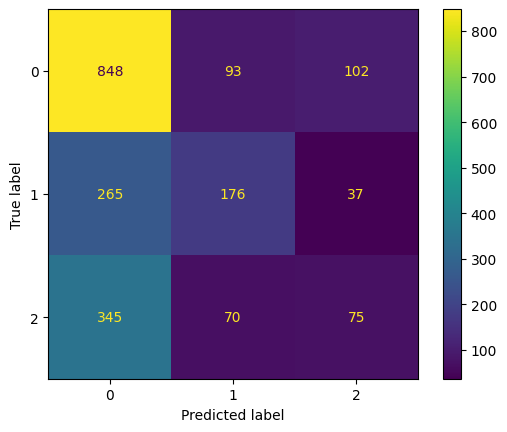

In [300]:
confusion_matrix2 = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix2,display_labels= [0,1,2])
confusion_matrix2.plot()

<b><u>Question 24 Answer: </u> The model correctly classified 848 'Built-up Areas and Gardens' instances. It incorrectly labelled 93 as 'Arable' which were actually 'Built-up Areas and Gardens' and 102 were incorrectly labelled as 'Improved Grassland. This model was better at classifying testing data as 'Built-up Areas and Gardens' than the decision tree.

The model correctly labelled 176 instances as 'Arable' but labelled 265 'Arable instances incorrectly as 'Built-up Areas and Gardens' based on the test data. It incorrectly labelled 37 instances of 'Arable' test data as 'Improved Grassland' based on the NO2 and SO2 readings provided in the test data.

The model labelled 75 instances correctly as 'Improved Grassland' given the test data of annual mean NO2 and SO2 readings. It incorrectly labelled 345 instances of 'Improved Grassland' as 'Built-up Areas and Gardens' and incorrectly classified 70 instances as 'Arable' when they were in fact 'Improved Grassland'.

This model was good at predicting 'Built-up Areas and Gardens' correctly based on the NO2 and SO2 readings. However it was not very good at clasifying 'Arable' land correctly and classifying 'Improved Grassland'.

<br>

__Question 25: Compare the statistical and visual results of the classification algorithms. Which is most effective, and does this vary by category? _(2 marks)___
<br>
__Hint:__ Remember the meaning of the classes: 0 = Built-up Areas and Gardens, 1 = Arable, 2 = Improved Grassland

<b><u>Question 25 Answer: </u> The confusion matrices show that k nearest neighbours was very good at correctly classifying the 'Built-up Areas and Gardens' data. The decision tree was good at this too but was less accurate than the k nearest neighbours algorithm. However, both models were best at correctly predicting this category than the other land types.

The confusion matrices shows that the decision tree was marginally better at predicting 'Arable' land correctly than the k nearest neighbours model by predicting 9 more instance correctly.

The matrices show that neither model was very good at predicting 'Improved Grassland' correctly. However, the k nearest neighbours model predicted only 75 correctly which was much worse than the decision tree did (it classified 162 correctly).

The statistical metrics from the decision tree model (model score, precision and recall) are all slightly lower than the metrics for the k nearest neighbours model. The recall for k nearest neighbours was 0.55 compared to 0.48 for the decision tree meaning that 55% of predictions were correct for k nearest neighbours compared to 48% for the decision tree.

The average accuracy for k nearest neighbours was 0.546 compared to 0.483 for the decision tree. This means that the mean accuracy for the k nearest neighbours model is higher.

Overall, the k nearest neighbours was most effective at classifying the 'Built-up Areas and Gardens' but the decision tree was slightly more effective at predicting 'Arable' and moderately more effectove at predicting 'Improved Grassland' based on the confusion matrices.

On the whole, I would choose the decision tree to classify this data as even though it has lower precision, recall and score, it is all round moderately accurate at predicting all three land types correctly compared to the k nearest neighbours. K nearest neighbours is very good at predicting 'Built-up Areas and Gardens' but quite bad at predicting 'Improved Grassland' and similar to the decision tree at predicting 'Arable'.

<br>

## Regression

You've now explored different patterns in your data using correlations, clustering, and classification. It's now time to return to your original 2020 data to explore the linear relationships with a simple linear regression. First you'll calculate the ratio of NO₂/NOₓ, then you'll predict the amount of SO₂ based on NO₂, NOₓ, and the dummy variables you created earlier.


__(total: 14 marks)__

Go back to your original `pollution` data with the expanded range of land cover types. You should already have extra dummy variables you created for all land cover types earlier. Create a subset called `pollution_subset` that only includes data for the year 2020.

In [301]:
pollution_subset = LCPnoNAno2081[LCPnoNAno2081['Year'] == 2020]

 Create a new variable in `pollution_subset` called `NOx_NO2_Ratio`. As we are interested in NOx relative to NO2, divide NOx by NO2

In [302]:
pollution_subset['NOx_NO2_Ratio'] = (pollution_subset['NOx']/pollution_subset['NO2'])

In [303]:
pollution_subset

,lau214cd,Year,Dominant land cover,NO2,NOx,SO2,Lc_Arable,Lc_Broadleaf Woodland,Lc_Built-up Areas and Gardens,Lc_Coastal,Lc_Coniferous Woodland,Lc_Freshwater,Lc_Improved Grassland,"Lc_Mountain, Heath, and Bog",Lc_Semi-natural Grassland,NOx_NO2_Ratio
3,UKC1101033,2020,Built-up Areas and Gardens,0.935884,1.246932,0.158346,False,False,True,False,False,False,False,False,False,1.332358
10,UKC1101034,2020,Built-up Areas and Gardens,0.834387,1.093537,0.137382,False,False,True,False,False,False,False,False,False,1.310587
17,UKC1101035,2020,Built-up Areas and Gardens,4.242182,5.658277,0.755658,False,False,True,False,False,False,False,False,False,1.333813
24,UKC1101036,2020,Built-up Areas and Gardens,2.044993,2.749600,0.359211,False,False,True,False,False,False,False,False,False,1.344552
31,UKC1101037,2020,Arable,2.325949,3.034255,0.338509,True,False,False,False,False,False,False,False,False,1.304524
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59615,UKh2314024,2020,Built-up Areas and Gardens,1.619516,2.187918,0.203207,False,False,True,False,False,False,False,False,False,1.350971
59622,UKh2314025,2020,Built-up Areas and Gardens,2.437782,3.334951,0.282689,False,False,True,False,False,False,False,False,False,1.368027
59629,UKh2314026,2020,Built-up Areas and Gardens,2.787724,3.748928,0.267699,False,False,True,False,False,False,False,False,False,1.344799
59636,UKh2314027,2020,Built-up Areas and Gardens,2.824657,3.850120,0.265620,False,False,True,False,False,False,False,False,False,1.363040


Earlier we checked for missing values, but sometimes, data will have 0 values present. If any zeros were present in the above calculation, then `NOx_NO2_Ratio` will have NaNs present. You will not be able to run an OLS in this case, so lets check for missing values again, this time only for the `NOx_NO2_Ratio`, and remove any rows with missing values.

In [304]:
print(pollution_subset['NOx_NO2_Ratio'].isna().sum())
pollution_subset = pollution_subset.dropna()
pollution_subset.shape

266


(8255, 16)

__Question 26: We're going to build a linear regression model, but first we need to check for multicollinearity between our variables. Explain what multicollinearity is, and why it's important to check for _(2 marks)___

<b><u> Question 26 Answer:</u>Multicollinearity is when two or more variables are highly correlated with each other. In the case of linear regression, it refers to when two or more independent/predictor variables are highly correlated with each other.

It is important to check for this when doing a regression as multicollinearity between variables can reduce the model's reliability, reduces power of a model and cause difficulty in isolating the specific independent variables that explain specific proportions of variation in a dependent variable in a regression model. Inaccuracy that multicollinearity causes can result in wider confidence intervals and larger standard errors.</b>

__Question 27: Now check for multicollinearity using `heatmap`. If there are any associations above 0.9, remove one of these variables (remove the one that comes later alphanumerically, for consistency- hint; numbers proceed letters) _(2 marks)___

*Hint: for the heatmap add the following parameters to make sure you can read the table:* `annot_kws={"size": 8}, fmt=".2f"`

<Axes: >

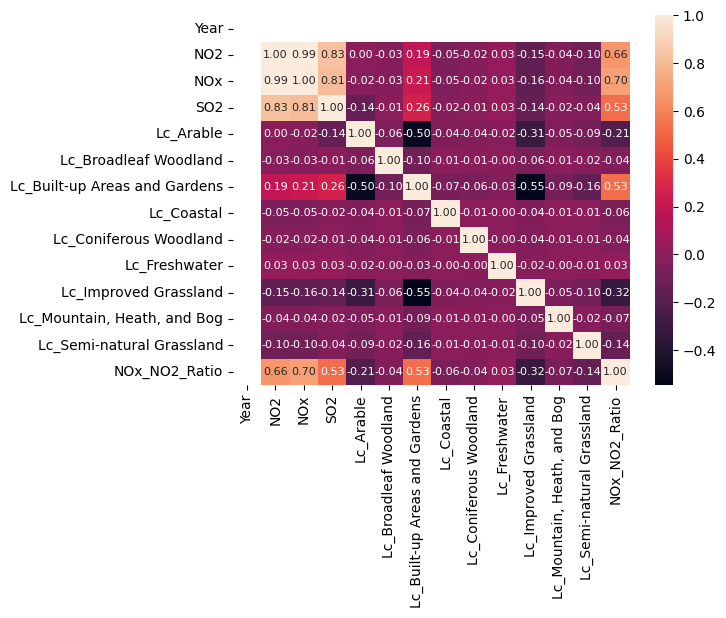

In [305]:
sns.heatmap(pollution_subset.corr(numeric_only=True), annot=True, fmt=".2f", annot_kws={"size": 8})

<b><u>Question 27 Answer:</u> The correlation between NO2 and NOx is very high and above 0.9 (0.99) thus they can be considered collinear. As NOx is alphanumerically 2nd in order compared to NO2, NOx will be removed from the dataset.

In [306]:
pollution_subset = pollution_subset.drop('NOx', axis=1)

In [307]:
pollution_subset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8255 entries, 3 to 59636
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   lau214cd                       8255 non-null   object 
 1   Year                           8255 non-null   int64  
 2   Dominant land cover            8255 non-null   object 
 3   NO2                            8255 non-null   float64
 4   SO2                            8255 non-null   float64
 5   Lc_Arable                      8255 non-null   bool   
 6   Lc_Broadleaf Woodland          8255 non-null   bool   
 7   Lc_Built-up Areas and Gardens  8255 non-null   bool   
 8   Lc_Coastal                     8255 non-null   bool   
 9   Lc_Coniferous Woodland         8255 non-null   bool   
 10  Lc_Freshwater                  8255 non-null   bool   
 11  Lc_Improved Grassland          8255 non-null   bool   
 12  Lc_Mountain, Heath, and Bog    8255 non-null   bool 

__Question 28: _(8 marks)___
__Build a linear regression model to predict the SO₂ for each land cover type. Use 'Lc_Freshwater' as your omitted reference category__
<BR>
__a) What is the R-squared value of the model, and what does this mean? (to 3 decimal places)__ <br>
__b) Which variables are statistically significant at the 5% level?__ <br>
__c) What are the regression coefficients of the statistically significant variables? (to 3 decimal places)__ <br>
__d) Briefly explain what these findings mean.__

In [308]:
import statsmodels.api as sm

x_regression = pollution_subset[['NO2','Lc_Arable','Lc_Broadleaf Woodland','Lc_Built-up Areas and Gardens','Lc_Coastal','Lc_Coniferous Woodland','Lc_Improved Grassland','Lc_Mountain, Heath, and Bog','Lc_Semi-natural Grassland','NOx_NO2_Ratio']]
y_regression = pollution_subset['SO2']
x_regression = sm.add_constant(x_regression)
MRmodel = sm.OLS(y_regression,x_regression.astype(float)).fit()
print(MRmodel.summary())

                            OLS Regression Results                            
Dep. Variable:                    SO2   R-squared:                       0.721
Model:                            OLS   Adj. R-squared:                  0.721
Method:                 Least Squares   F-statistic:                     2135.
Date:                Thu, 05 Dec 2024   Prob (F-statistic):               0.00
Time:                        23:41:41   Log-Likelihood:                 4351.3
No. Observations:                8255   AIC:                            -8681.
Df Residuals:                    8244   BIC:                            -8603.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

<b><u>Question 28 Answer:</u>

a) The R-square value is 0.721 (rounded to 3 decimal places) for this model. This means that all of the explanatory variables entered into the model account for and explain 72.1% of the variation of the SO2 levels measured in LAUs in England and Wales in 2020 that were entered into the model.

b) The variables that are statistically significant at the 5% level are 'Lc_Arable', 'NOx_NO2_Ratio', and 'NO2'.

c) The regression coefficients of the statistically significant variables are 'Lc_Arable' = -0.151,'NOx_NO2_Ratio' = -0.736, and 'NO2' = 0.160 (all rounded to 3 decimal places).

d) The fact that these three variables are statistically significant at the 5% level ('Lc_Arable', 'NOx_NO2_Ratio', and 'NO2') mean that these variables have a statistically significant effect on the variation of the dependent variable (SO2 levels). This means we can be 95% confident that change in any of these independent variables will have an effect/cause a change in the SO2 levels measures in a given area. If the dominant type of land covering an area is Arable, if the NOx/NO2 ratio changes or the NO2 level measures in an area changes, there is 95% chance it will have an effect on the SO2 levels measured in the area.

The regression coefficients indicate the type of change that will happen to the dependent variable (SO2 level measured) if the corresponding independent variable changes. 'Lc_Arable' has a coefficient of -0.151 meaning that if  'Lc_Arable' was a continuous variable and increased by 1, the SO2 level measured is predicted by the model to decrease by 0.151 as it is negative. However, as this variable is actually categorical, this means that 'Lc_Arable' cannot actually increase or decrease in numerical value when in its original coding, it can only be true or false. Thus the coefficient actually indicates that if an LAU has a dominant land cover type of 'Arable', the model predicts the SO2 level measured in that area would be 0.151 times less than if the land type was not 'Arable'.

'NO2' has a coefficient of 0.160 meaning that if the NO2 level in an area increases by 1, the SO2 level measured is predicted by the model to increase by 0.160 as it is positive.

'NOx_NO2_Ratio' has a coefficient of -0.736 meaning that if the ratio of NOx:NO2 in an area increases by 1, the model predicts that the SO2 level in this area is likely to decrease by 0.736. </b>

<br>

__Question 29: A linear regression model can tell us about correlations. Explain the difference between correlations and causation, and whether we can infer causation from the results of this model _(2 marks)___

<b><u>Question 29 Answer: </u> Correlation is when two variables appear to have a relationship with one another. This means that the variables have some form of relationship with one another but the type of relationship and the factors that influence that relationship may not be known and cannot be interpreted from correlation alone.

Causation is when a change in one variable has an effect on another variable or one event happening results in another event occuring.

We cannot infer causation directly from regression results alone as there could be a multitude of other variables that influence this dependent variable of SO2 levels in an area of the UK that we have not included in the model such as changes in the weather.The regression results provide good evidence for causation but as the data did not come from a controlled experiment , thus there are potentially many confounding variables that have not been investigated in the model including the omitted land cover type Freshwater. Transformations were not performed on the data either to investgate potential non-linear relationships which could have resulted in other variables having effects on the SO2 level recorded in 2020. Thus, many other factors should be considered and further more nuanced analysis should be carried out before inferring causation.

</b>

<br>

## Data Joining

You'll now proceed to some spatial modelling, so first load into the `LAU2_Dec_2014_FCB_in_England_and_Wales` shape file, and call it `lau2`.

Remember, the LAU2 ID is called `lau214cd`.

In [309]:
pip install folium mapclassify matplotlib_scalebar

In [310]:
import numba
import matplotlib
import palettable as pltt
import descartes
from pysal.viz import mapclassify
import statsmodels.api as sm
import scipy.stats as stats
from matplotlib_scalebar.scalebar import ScaleBar
import folium
import mapclassify
import libpysal
from libpysal import weights
from pysal.lib import weights
from splot.libpysal import plot_spatial_weights
from pysal.lib import io
import contextily as cx
from pysal.explore import esda
from pysal.viz import splot
#add set the position of the legend
from splot.esda import moran_scatterplot, lisa_cluster, plot_local_autocorrelation
#add patches for custom legends
import matplotlib.patches as mpatches

In [311]:
import geopandas as gpd
lau2 = gpd.read_file('/content/LAU2_England_Wales.shp')

In [312]:
lau2

,lau214cd,lau214nm,GlobalID,geometry
0,UKI2101021,Abbey,5b4b8a45-60dd-4bf1-8f56-65e13e5b216a,"MULTIPOLYGON (((544395.7 184883.2, 544476.7 18..."
1,UKI2101022,Alibon,f97a6fac-79cf-4625-af24-dd143e45b249,"POLYGON ((549604.1 185773.2, 549613.1 185629.9..."
2,UKI2101023,Becontree,e53d2a89-5b84-40c3-8310-a299376bd523,"POLYGON ((547563.4 186223.9, 547548.7 186185.2..."
3,UKI2101024,Chadwell Heath,04b5ba13-0b25-486a-9ede-44e1c9d0b1ab,"POLYGON ((548881 191087.6, 548877.3 191055.8, ..."
4,UKI2101025,Eastbrook,10afb7ad-4277-4112-b86a-00a30cb25e15,"POLYGON ((551552.9 187363.4, 551554.8 187358.9..."
...,...,...,...,...
8507,UKL1100094,Lligwy,43858b6d-4dba-4668-87d4-53b0429d8696,"MULTIPOLYGON (((248597.3 388874.6, 248614.3 38..."
8508,UKL1100095,Seiriol,09756995-f6a2-416f-9045-39695dcdd708,"MULTIPOLYGON (((258961.9 382347.8, 258970.2 38..."
8509,UKL1100096,Talybolion,6f272cbf-305a-4323-aa06-d5ac5ad910c2,"MULTIPOLYGON (((233303.5 394018.3, 233296.9 39..."
8510,UKL1100097,Twrcelyn,c74c6396-e54b-4764-a97e-9eedcdb49522,"MULTIPOLYGON (((239006.2 395294.4, 239013.6 39..."


Now join the data to the `pollution_subset` data frame, based on the `lau214cd`. Call the new dataset `pollution_lau2`.

In [313]:
pollution_lau2 = lau2.join(pollution_subset.set_index('lau214cd'), on = 'lau214cd')

In [314]:
pollution_lau2

,lau214cd,lau214nm,GlobalID,geometry,Year,Dominant land cover,NO2,SO2,Lc_Arable,Lc_Broadleaf Woodland,Lc_Built-up Areas and Gardens,Lc_Coastal,Lc_Coniferous Woodland,Lc_Freshwater,Lc_Improved Grassland,"Lc_Mountain, Heath, and Bog",Lc_Semi-natural Grassland,NOx_NO2_Ratio
0,UKI2101021,Abbey,5b4b8a45-60dd-4bf1-8f56-65e13e5b216a,"MULTIPOLYGON (((544395.7 184883.2, 544476.7 18...",2020.0,Built-up Areas and Gardens,3.667555,0.528643,False,False,True,False,False,False,False,False,False,1.544851
1,UKI2101022,Alibon,f97a6fac-79cf-4625-af24-dd143e45b249,"POLYGON ((549604.1 185773.2, 549613.1 185629.9...",2020.0,Built-up Areas and Gardens,2.883153,0.545412,False,False,True,False,False,False,False,False,False,1.466166
2,UKI2101023,Becontree,e53d2a89-5b84-40c3-8310-a299376bd523,"POLYGON ((547563.4 186223.9, 547548.7 186185.2...",2020.0,Built-up Areas and Gardens,3.948112,0.618580,False,False,True,False,False,False,False,False,False,1.473691
3,UKI2101024,Chadwell Heath,04b5ba13-0b25-486a-9ede-44e1c9d0b1ab,"POLYGON ((548881 191087.6, 548877.3 191055.8, ...",2020.0,Built-up Areas and Gardens,3.760137,0.497366,False,False,True,False,False,False,False,False,False,1.430205
4,UKI2101025,Eastbrook,10afb7ad-4277-4112-b86a-00a30cb25e15,"POLYGON ((551552.9 187363.4, 551554.8 187358.9...",2020.0,Improved Grassland,7.692089,1.233112,False,False,False,False,False,False,True,False,False,1.468152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8507,UKL1100094,Lligwy,43858b6d-4dba-4668-87d4-53b0429d8696,"MULTIPOLYGON (((248597.3 388874.6, 248614.3 38...",2020.0,Improved Grassland,0.769644,0.223299,False,False,False,False,False,False,True,False,False,1.255660
8508,UKL1100095,Seiriol,09756995-f6a2-416f-9045-39695dcdd708,"MULTIPOLYGON (((258961.9 382347.8, 258970.2 38...",2020.0,Improved Grassland,0.903284,0.269537,False,False,False,False,False,False,True,False,False,1.255040
8509,UKL1100096,Talybolion,6f272cbf-305a-4323-aa06-d5ac5ad910c2,"MULTIPOLYGON (((233303.5 394018.3, 233296.9 39...",2020.0,Improved Grassland,0.863002,0.223703,False,False,False,False,False,False,True,False,False,1.252564
8510,UKL1100097,Twrcelyn,c74c6396-e54b-4764-a97e-9eedcdb49522,"MULTIPOLYGON (((239006.2 395294.4, 239013.6 39...",2020.0,Improved Grassland,0.775107,0.240469,False,False,False,False,False,False,True,False,False,1.254570


<br>

## Spatial Analysis

Now you have your final dataset, you can begin to explore the spatial patterns, and whether a spatial regression model is needed.

__(total: 31 marks)__

<br>

__Question 30: Create a choropleth of the SO₂ in each LAU. Use an appropriate colour scheme, and number of quantiles. Remember to not let the legend cover the map. Explain your choice of colour scheme and what you think the choropleth shows _(4 marks)___

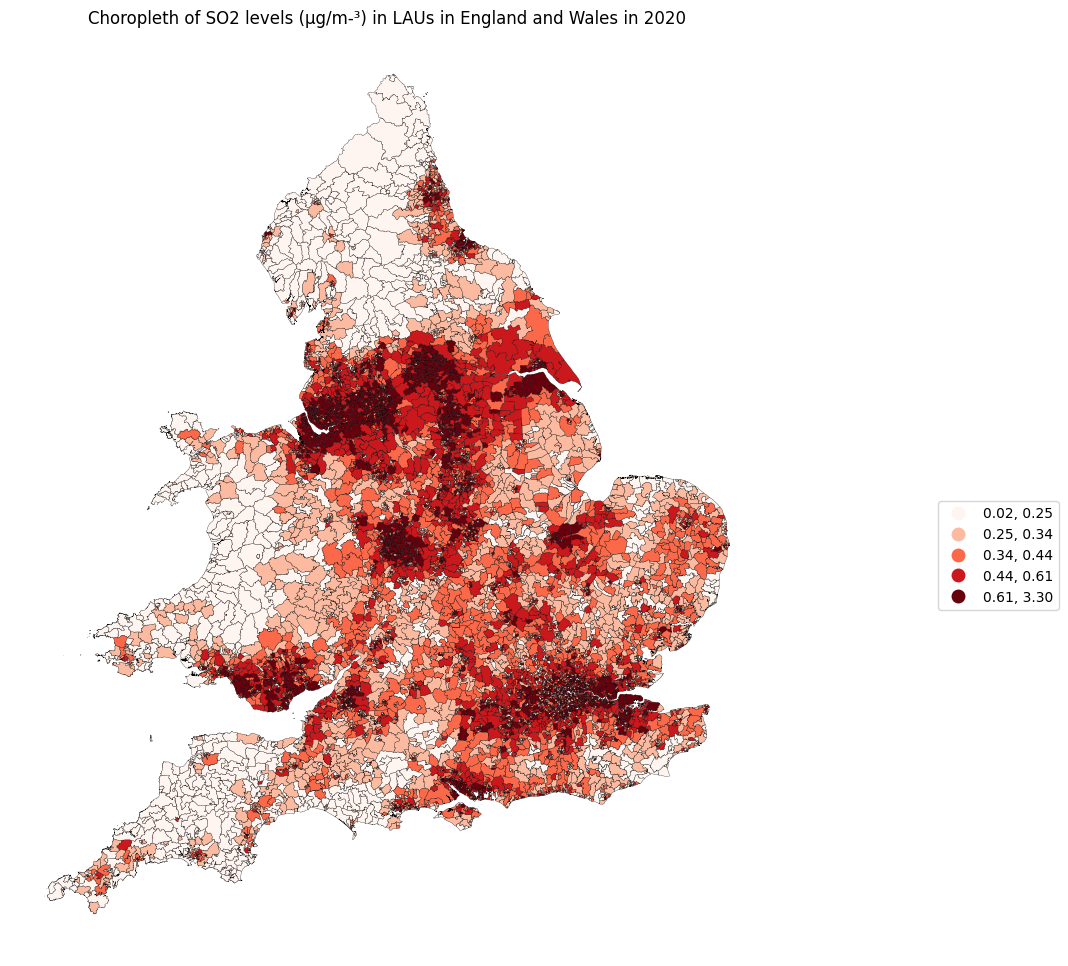

In [315]:
pollution_lau2 = pollution_lau2.dropna()
fig, ax = plt.subplots(1, figsize=(12, 12))
pollution_lau2.plot(ax = ax,column = 'SO2', scheme = 'quantiles', k = 5,legend = True, cmap = 'Reds', edgecolor = 'black', linewidth = 0.2)
plt.title('Choropleth of SO2 levels (µg/m-³) in LAUs in England and Wales in 2020') #add a title
leg = ax.get_legend()
leg.set_bbox_to_anchor((1.4,0.5))
ax.set_axis_off()
plt.show()

<b><u>Question 30 Answer:</u>I chose this colour scheme as it is sequential so the increasing gradient of the shade of red is congruent  with the increase in SO2 measured in each LAU shown in the map. The colour choice also shows the differences in SO2 levels between LAUs clearly with the contrasting lightness/darkness of the shade of red. The darker the red, the more SO2 there is in this area of England/Wales. This makes it easy to assess the relative difference in SO2 levels between areas in England and Wales. This is also an appropriate choice of colour to frame the context and meaning of SO2 levels in LAUs to the person viewing the map as red is generally associated with negative attributes and higher SO2 levels are more negative for the environment thus darker shades of red for higher SO2 levels express this. The number of quantiles and the appropriate difference between shades of red clearly show the quantile that each section of England and Wales fall into. The number of quantiles mean that there is enough of a contrast between shades of red that one can easily differentiate between the shades of red and there are still enough quantiles to inform an individual about how SO2 levels vary across England and Wales.

I think the choropleth shows there are higher levels of SO2 in areas of urban concentration or high population density. This is because London and Greater London areas are dark red (0.61-3.30 µg/m-³) and in the highest quantile of SO2. This is also the case for areas in and around Birmingham, Liverpool on the north west coast of England and Manchester which is also coloured dark red (0.61-3.30 µg/m-³) and is positioned east of Liverpool in the same region of dark red (0.61-3.30 µg/m-³). These are in contrast to less densely populated areas and protected outstanding areas of natural beauty where urban development is limited such as north Devon and Cumbria/the Lake District which are primarily coloured the lightest shade of red (0.02-0.25 µg/m-³)</b>


<br>

__Question 31:  To statistically explore the spatial patterns, we begin by calculating weights. Calculate K-nearest neighbours based on the LAU column using 20 neighbours. Using the KNN weights: What is the Moran's I value for the SO₂ (to 3 d.p.)? Is it statistically significant? Explain what this means. (_5 marks_)__

In [316]:
w_k = weights.KNN.from_dataframe(pollution_lau2, k=20,  use_index = False, ids = 'lau214cd')
#w_k.transform = 'R'
#w_k_card = pd.Series(w_k.cardinalities)

In [317]:
mi = esda.Moran(pollution_lau2['SO2'], w_k)

In [318]:
print(mi.I)
print(mi.p_sim)

0.4355333064303297
0.001


<b><u>Question 31 Answer:</u> The Moran's I value for the SO2 is 0.436 (rounded to 3 decimal places). The p-value for the Moran's I value is 0.001 meaning that it is significant at the 5% significance level. As Moran's I is positive (it can range from -1 to 1), this means the data are spatially clustered more than we would expect if the SO2 measurements across England and Wales were randomly distributed (if randomly distributed, Moran's I would be 0). As the value is statistically significant, this means that for a given LAU in England and Wales, the SO2 measurement in that LAU is 95% likely to be more similar to the SO2 values measured in neighbouring LAUs than one would expect by chance. </b>

<br>
    
__Question 32: Create a Moran scatterplot and explain what you observe (_2 marks_)__

(<Figure size 700x700 with 1 Axes>,
 <Axes: title={'center': 'Moran Scatterplot (0.44)'}, xlabel='Attribute', ylabel='Spatial Lag'>)

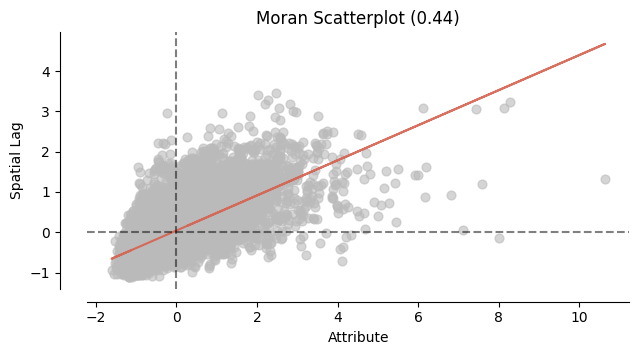

In [319]:
moran_scatterplot(mi)

<b><u>Question 32 Answer:</u> The Moran scatter plot shows Attribute on the x axis. The x value of each point (LAU) is the SO2 value of a LAU subtracted from the number of standard deviations away that particular SO2 value is from the mean SO2 of the whole data set (in other words, the x value is the standardised SO2 value for each LAU).

The y value for each data point is the spatial lag. This is the standardised mean SO2 level of the neighbouring clusters for that LAU/data point.

The line of best fit for the scatter plothas a positive slope with a gradient of 0.44 (included in the title and this is the Moran's I value). As it is positive this means that there is positive spatial autocorrelation meaning that there is a spatial trend in the distribution of high and low SO2 values across England and Wales and the clustering patterns of high and low SO2 values are not by chance. As the data points generally follow the positive trend of the line and are distributed centrally around the line with few outliers, this indicates the data fit the line of best fit moderately well.

Data in the top right hand quadrant of a Moran's I scatter plot contain data points representing LAUs with high SO2 levels that are also surrounded by neighbours that have high SO2 levels and they are significantly spatially correlated (HH/high-high). There seems to be the most data in this category but as the data points overlap it is difficult to ascertain.

Data in the bottom right quadrant represents LAUs that have high SO2 levels and are surrounded by LAUs with low SO2 levels (HL/high-low).

Data in the bottom left quadrant represent LAUs that have low SO2 levels but are surrounded by LAUs with low SO2 values (LL/low-low).

Data in the top left quadrant represent LAUs that have low levels of SO2 and are surrounded by LAUs with high levels of SO2 (LH/low-high). </b>



<br>

__Question 33: Create a LISA cluster map of the average SO₂ emissions, and comment on what you observe, including what is meant by the different cluster types (_4 marks_)__

In [237]:
lisa = esda.Moran_Local(pollution_lau2['SO2'], w_k)

Text(0.5, 1.0, 'LISA Cluster Map showing Spatial Correlation of Average SO2 emissions in LAUs in England and Wales')

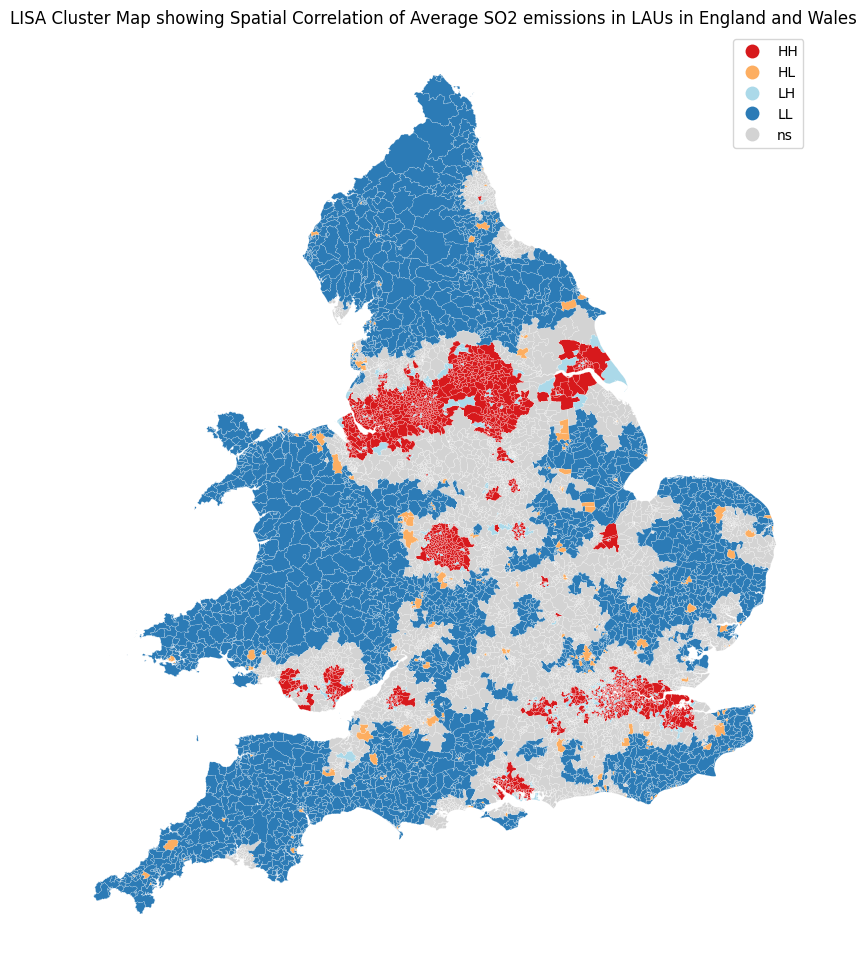

In [247]:
fig, ax = plt.subplots(figsize = (12,12))
fig = lisa_cluster(lisa, pollution_lau2, ax=ax)
plt.title('LISA Cluster Map showing Spatial Correlation of Average SO2 emissions in LAUs in England and Wales')

<b><u>Question 33 Answer</u>: The LISA plot categorises the LAUs into different coloured categories depending on what type of spatial autocorrelation the neighbouring LAUs have with a given LAU. The correlation in this case is based on the SO2 levels measured in each LAU.

If a LAU is coloured dark blue (LL) it means that it is significantly spatially correlated with the neighbouring LAUs surrounding it and they all have low SO2 levels.

If a LAU is coloured light blue (LH), this means the LAU is significantly correlated with the neighbouring LAUs and that particular LAU had a low measurement of SO2 but are surrounded by LAUs that have high SO2 measurements.

If a LAU is coloured yellow/orange (HL), this means it is significantly correlated with the neighbouring LAUs and the HL LAU has a high SO2 measurement but is surrounded by LAUs which had low levels of SO2.

If a LAU is coloured red (HH), this means it is significantly correlated with its neighbouring LAUs and the HH LAU has a high reading of SO2 and is surrounded by LAUs that also have high SO2 levels.

This LISA map shows that there are regions of significantly high spatially correlated SO2 levels around London and South Essex where it borders London. It also shows the same trend around Birmingham, in a horizontal belt across the north of England from Liverpool, through Manchester and including Leeds and Sheffield. There are also smaller areas showing the same correlation in South Wales (around Cardiff), Southampton, Bristol, and Hull on the north east coast.

There are significantly large areas of low-low (LL) spatial correlation of SO2 measurements across generally rural areas of England and Wales such as most of Cornwall, northern England, Devon, Wales and Norfolk.

There are very few and isolated areas where there is high-low (HL) spatial correlation of SO2 levels in LAUs. These are found predominantly scattered sparsely around the large areas with low-low correlation or LAUs which did not show significant spatial correlation of SO2 levels with neighbouring LAUs (ns - coloured grey on the map).

There are very few areas of low-high (LH) spatial correlation and the few that are shown are situated in the periphery of HH areas such as the outskirts of Greater London and the outskirts of Birmingham's HH area. However there are a couple LH LAUs that are neighbouring ns areas such as around Taunton in Somerset.

Overall, the map seems to show a trend of spatial correlation of high levels of SO2 surrounded by areas that also have high levels of SO2 around centres of high urban activity such as cities like London and Birmingham. There is correlation of low SO2 levels being found in areas that are less densely populated and these LAUs are also surrounded by LAUs with low SO2 levels. This includes Cornwall and Cumbria. </b>

<br>
As there are spatial patterns in this data, this suggests there may be underlying spatial processes, which we can attempt to capture with a GWR model. Usually, you would need to calculate the bandwidth yourself. For simplicity, the bandwidth is specified for you here.
<br>
<br>

__Question 34: Now extend the ealier linear model to a Geographically Weighted Regression, using a bandwidth of 4200. Report:__ <br>

__a) The local correlation coefficient for NOx/NO2 mean (GWR mean) _(2 marks)___ <br>

__b) Your findings of whether/how this model has accounted for underlying spatial patterns in the data _(3 marks)___

As we have polygons, we need to extract out the centroid for the GWR. We've done this for your below.
You can then set these as your co-ordinates, and continue with your GWR model.

In [ ]:
from mgwr.gwr import GWR, MGWR
from mgwr.sel_bw import Sel_BW

In [ ]:
pollution_lau2['geometry'] = pollution_lau2.geometry.centroid #calculate the centroid
pollution_lau2['x'] = pollution_lau2.geometry.x #extract x
pollution_lau2['y'] = pollution_lau2.geometry.y #extract y

In [ ]:
pollution_lau2 = pollution_lau2.replace({True: 1, False: 0})

<ipython-input-143-a16e4472a4aa>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pollution_lau2 = pollution_lau2.replace({True: 1, False: 0})


In [ ]:
g_coords = list(zip(pollution_lau2['x'],pollution_lau2['y']))
x = np.asarray(pollution_lau2[['NO2','Lc_Arable','Lc_Broadleaf Woodland','Lc_Built-up Areas and Gardens','Lc_Coastal','Lc_Coniferous Woodland','Lc_Improved Grassland','Lc_Mountain, Heath, and Bog','Lc_Semi-natural Grassland','NOx_NO2_Ratio']]).reshape((-1,10))
y = pollution_lau2['SO2'].values.reshape((-1,1))

In [ ]:
gwr = GWR(g_coords, y, x, 4200)

In [ ]:
gwr_results = gwr.fit()
gwr_results.summary()

Model type                                                         Gaussian
Number of observations:                                                8246
Number of covariates:                                                    11

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                            166.245
Log-likelihood:                                                    4395.701
AIC:                                                              -8769.401
AICc:                                                             -8767.363
BIC:                                                             -74092.731
R2:                                                                   0.719
Adj. R2:                                                              0.719

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

<b><u>Question 34 Answer</u>:

a) The local correlation coefficient for NOx/NO2 mean is -0.253.

b) This model has adapted accounted for underlying spatial patterns as the GWR (which accounts for the influence of independent variables to vary across space compared to the global regression) has a higher adjusted R-square value (0.825) than the global regression (0.719). This means that accounting for how the independent variables might affect SO2 levels in different areas of the UK in different ways accounts for 10.6% (100*(0.825-0.719))
 of the variation in the SO2 levels across England and Wales in 2020. The main difference between these models is that the GWR varies the weighting of each independent variable on the SO2 level in a given LAU based on the independent variable features that are found in neighbouring LAUs on the SO2 in their LAU, thus concluding how influential each independent variable is depending on where a particular LAU is in space. Thus, it is likely that the introduction of this consideration is how the model has accounted for underlying spatial patterns and the increase in adj. R-square between the models indicates its success.

 However, if we plot the residuals of the GWR regression, this would give us further indication as to whether allowing the coefficients to vary across space according to the parameters we set (like the bandwidth) has accounted for spatial autocorrelation in the dataset.
</b>

__Question 35: Now plot how the regression coefficients for the NOX/NO2 ratio and 'Built-up Areas and gardens' across space, and discuss your findings, related to how these variables are associated with the SO2 emissions. (_6 marks_)__

In [ ]:
pollution_lau2['GWR_NOx/NO2_coefficient'] = gwr_results.params[:,10]
pollution_lau2['GWR_Built-Up_coefficient'] = gwr_results.params[:,4]

In [ ]:
pollution_lau2

,lau214cd,lau214nm,GlobalID,geometry,Year,Dominant land cover,NO2,SO2,Lc_Arable,Lc_Broadleaf Woodland,...,Lc_Coniferous Woodland,Lc_Freshwater,Lc_Improved Grassland,"Lc_Mountain, Heath, and Bog",Lc_Semi-natural Grassland,NOx_NO2_Ratio,x,y,GWR_NOx/NO2_coefficient,GWR_Built-Up_coefficient
0,UKI2101021,Abbey,5b4b8a45-60dd-4bf1-8f56-65e13e5b216a,POINT (544215.878 184356.672),2020.0,Built-up Areas and Gardens,3.667555,0.528643,0,0,...,0,0,0,0,0,1.544851,544215.877610,184356.671957,-0.520563,-0.138799
1,UKI2101022,Alibon,f97a6fac-79cf-4625-af24-dd143e45b249,POINT (549061.587 185152.943),2020.0,Built-up Areas and Gardens,2.883153,0.545412,0,0,...,0,0,0,0,0,1.466166,549061.586998,185152.942995,-0.511701,-0.142899
2,UKI2101023,Becontree,e53d2a89-5b84-40c3-8310-a299376bd523,POINT (547000.356 186088.281),2020.0,Built-up Areas and Gardens,3.948112,0.618580,0,0,...,0,0,0,0,0,1.473691,547000.355555,186088.280918,-0.513900,-0.141277
3,UKI2101024,Chadwell Heath,04b5ba13-0b25-486a-9ede-44e1c9d0b1ab,POINT (548359.713 189490.849),2020.0,Built-up Areas and Gardens,3.760137,0.497366,0,0,...,0,0,0,0,0,1.430205,548359.712570,189490.848872,-0.507750,-0.142628
4,UKI2101025,Eastbrook,10afb7ad-4277-4112-b86a-00a30cb25e15,POINT (550789.866 186100.834),2020.0,Improved Grassland,7.692089,1.233112,0,0,...,0,0,1,0,0,1.468152,550789.865946,186100.834296,-0.507880,-0.144374
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8507,UKL1100094,Lligwy,43858b6d-4dba-4668-87d4-53b0429d8696,POINT (249933.467 382455.402),2020.0,Improved Grassland,0.769644,0.223299,0,0,...,0,0,1,0,0,1.255660,249933.467449,382455.402270,-0.110699,0.117047
8508,UKL1100095,Seiriol,09756995-f6a2-416f-9045-39695dcdd708,POINT (258332.301 378062.082),2020.0,Improved Grassland,0.903284,0.269537,0,0,...,0,0,1,0,0,1.255040,258332.300689,378062.082216,-0.117253,0.123147
8509,UKL1100096,Talybolion,6f272cbf-305a-4323-aa06-d5ac5ad910c2,POINT (235531.494 385876.801),2020.0,Improved Grassland,0.863002,0.223703,0,0,...,0,0,1,0,0,1.252564,235531.493516,385876.800569,-0.106496,0.109961
8510,UKL1100097,Twrcelyn,c74c6396-e54b-4764-a97e-9eedcdb49522,POINT (243072.526 390307.257),2020.0,Improved Grassland,0.775107,0.240469,0,0,...,0,0,1,0,0,1.254570,243072.526242,390307.256621,-0.095700,0.109709


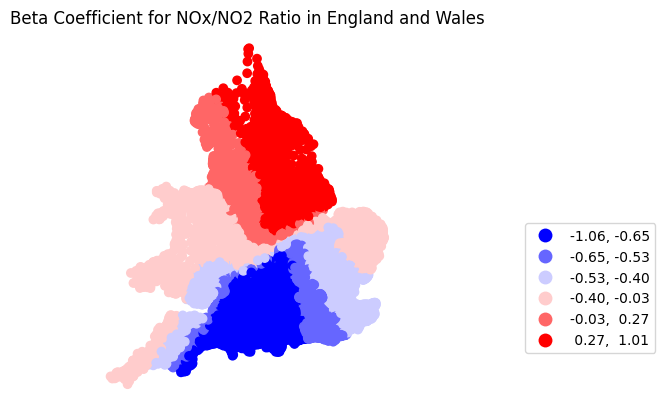

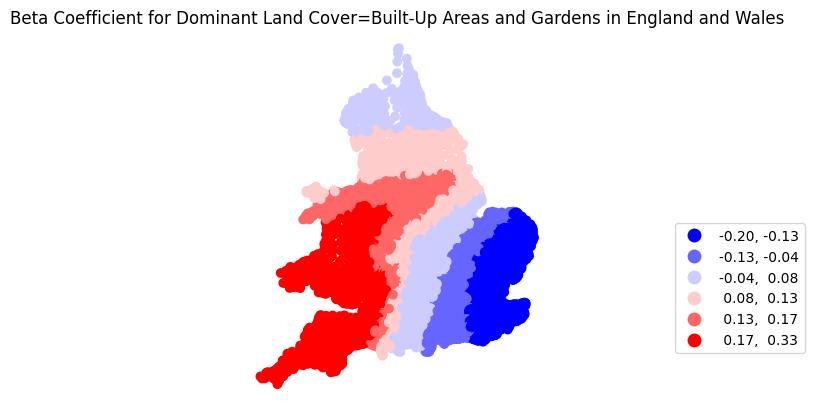

In [ ]:
# ax = plt.subplot(1,2,1)
ax = pollution_lau2.plot(column = 'GWR_NOx/NO2_coefficient', cmap = 'bwr', scheme = 'quantiles', k = 6, legend = True)
plt.title('Beta Coefficient for NOx/NO2 Ratio in England and Wales')
leg = ax.get_legend()
leg.set_bbox_to_anchor((1.4,0.5))
ax.set_axis_off()
plt.show()

# ax = plt.subplot(1,2,2)
ax = pollution_lau2.plot(column = 'GWR_Built-Up_coefficient', cmap = 'bwr', scheme = 'quantiles', k = 6,legend = True)
plt.title('Beta Coefficient for Dominant Land Cover=Built-Up Areas and Gardens in England and Wales') #add a title
leg = ax.get_legend()
leg.set_bbox_to_anchor((1.4,0.5))
ax.set_axis_off()
plt.show()


<b><u>Question 35 Answer:</u> The top chart shows the cofficient of the NOx/NO2 ratio predicting SO2 levels in LAUs in England and Wales depending on which LAU in the UK is being focussed on.

This shows that in the south coast of England and south midlands, the NOx/NO2 ratio coefficient is between -1.06 and -0.65. This means that in this area, there is the strongest negative relationship between the NOx/NO2 ratio and the SO2 levels measured in 2020. This means in this area, if the ratio increases by 1, the SO2 level will decrease by a value between 0.20 and 1.06.

The periphery of this region extending towards london, Kent and Bristol have ratio coefficients between -0.65 and -0.53 meaning that the SO2 levels in these regions will decrease by an amount in this region if the ratio increases by 1.

Extending to the perimeter of the previous periphery are the areas with coefficients between -0.53 and -0.40. In these areas including Essex, Norfolk, Dorset, Devon and some of south Wales are predicted to experience decreases of SO2 between the two aforementioned coefficients if the Nox/No2 ratio increases by 1.

Areas of Cornwall, the rest of Wales, and Norfolk follow a similar trend but for coefficients between -0.40 and -0.03.

From the midlands to the north of England, the directionality of the coefficients change for the most part. Most of this area is darkest red with coefficients between 1.01 and 0.27. This means that if the NOx to NO2 ratio increases by 1, the SO2 levels in those regions are predicted to increase by between 0.27 and 1.01. The perimeter of this area could experience decreases in SO2 from 0.03 to increases in SO2 levels of 0.27.

In the second graph, this shows how the regression coefficient for whether the dominant land covering an LAU is "Built-up Areas and Gardens" changes depending on which LAU's SO2 reading is being predicted. This shows a pattern of most positive correlation coefficients (0.17-0.33) in south and central Wales, Cornwall, Devon, Dorset and Somerset. A perimeter around this area including north Wales, and the horizontal belt where Manchester and Liverpool lie have coefficients of 0.13-0.17. The further perimeter around this area including the north west tip of Wales and the remainder of North Yorkshire and East Yorkshire have coefficients for this explanatory variable between 0.08 and 0.13. These areas are all coloured in shades of red on the map. As this is a dummy variable, the relationship between this variable and the SO2 levels is that if the area is covered predominantly by Built-up Areas and Gardens, it is likely the SO2 reading will increase by the 1x the magnitude of coefficient. For example, if an LAU in Cornwall has a dominant land cover type of "Built-up Areas and Gardens", the SO2 reading in that area in 2020 is likely to be between 0.17 and 0.33 more than if that LAU was dominantly covered by a different land type.

In the second graph areas in the blue regions including Kent and Essex (darkest blue) have negative coefficients for dominant land cover="Built-up Areas and Gardens" (-0.20 to -0.13). Lighter blue areas bordering the darkest blue area that include London and north Norfolk have coefficients between -0.13 and -0.04. The remaining areas in the lightest blue shade (including northern England and the midlands) have coefficients ranging from-0.04 to 0.08. If the coefficient is negative, this means that if an LAU in this area with a negative coefficient has a dominant land cover of "Built-up Areas and Gardens", the LAU's SO2 level is likely to decrease by the magnitude of the coefficient. For example, for an LAU in north Norfolk, if it was mainly "Built-up Areas and Gardens", the predicted SO2 measurement would be between 0.13 and 0.04 less than if it was another land type. However, in the lightest blue areas, some of the coefficients are still positive as the upper boundary of this quantile is 0.08 so LAUs in this region with positive coefficients for this variable will likely be predicted to have a higher SO2 level if their dominant land cover type is "Built up Areas and Gardens" than if it wasn't.


<br>

__Question 36: Explain how Geographically Weighted Regression can be used to capture spatial processes in the data, whether there are furhter checks we could do, and what these results  can tell us about the relationship between land use and pollutants across space _(5 marks)___

<u><b> Question 36 Answer: </u> GWR can be used to capture spatial processes by observing the map plotting the coefficients of variables and how the coefficients of different variables vary across space. This shows how much of an influence those variables have on a dependent variable depending on the location being focussed on. If we plot the residuals in a similar fashion to the LISA clustering model and find there is no significant spatial autocorrelation in the GWR residuals or minimal amounts, this means the GWR has accounted for the spatial autocorrelation seen in the first LISA cluster map.

Further checks that could be done include conducting non-linear regressions to check whether there are quadratic, cubic, or logarithmic relationships between the independent variables and SO2 level measured in LAUs.We could also use temporal analysis methods such as ARIMA or Geographically and Temporally Weighted Regression to see if the SO2 levels vary seasonally. Different spatial models could also be computed to compare the results of the GWR against them like Spatial Lag models or extensions of GWR like Multiscale GWR which allows the bandwidth of each data point (LAU) to vary across space. This would be interesting to analyse in England as cities like London have a much wider influence over the surrounding geographic areas compared to smaller cities like Bath. In such a case as these two cities, the bandwidth could be adjusted to ensure that LAUs in London consider neighbours in a wider bandwidth range compared to smaller less influential cities like Bath.

As humans are the cause of such large amounts of pollutants being released into the atmosphere through industrial activity, behavioural analysis to understand why people choose to continue with practices that are harmful to the environment and why people choose not to take action against it and remain complicit could extend the analysis using API data from social media or survey or interview data. This could use neural networks and natural language processing models to understand the sentiment behind individuals' decisions to pollute the environment despite being informed about the causes and help inform policy and preventative strategies to change behaviour on a large scale and reduce pollutants being emitted into the environment.

OVerall, these results show that land use is related to pollutant levels measured across space in England and Wales. There seems to be higher levels of SO2 recorded in 2020 around large cities and urban areas compared to rural areas. A larger ratio between NOx and NO2 in a given LAU will likely cause increases in SO2 levels in more northern areas of England and decreases in SO2 levels in the south of England and Wales.If the dominant land type covering an area is "Built-up Areas and Gardens", it is likely that SO2 levels will be higher in Wales and the west of England but in the south east of England and very north of England, it is likely that SO2 levels will be lower if the dominant land covering an LAU is "Built up Areas and Gardens" rather than another type.

## End of Assessment 1
Well done on completing Assessment 1! See below for instructions on generating your PDF.

<br>

## ❗️Submission Instructions
The deadline for this assignment is 2pm on Friday 6th December, via the Minerva submission area.
You __must__ ensure you have __run your notebook in order__ prior to submission (to demonstrate that the code works), and saved your work as a PDF file.

### Creating a PDF:
On Colab, go to File > Print > Save as PDF.

Sometimes, on Chrome or Edge, this can cut off the bottom of your notebook- but this doesn't seem to be an issue on Safari or Firefox, so we recommend you try with one of these browsers first. If you're still having issues, follow the instructions below to export your notebook as a PDF via Google Drive.


__Step 1:__ Make sure you have a Google account, and save your notebook to Drive.

__Step 2:__ Run the following two cells, which connect your notebook to the Drive file path, and set up the export.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
!sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic pandoc

__Step 3:__ Copy the filepath to your notebook- either by using the folder icon on the left of Colab, or via your browser (making sure there are no spaces in the folder names). Then you can update the filepath below, and run the cell. It will save the PDF in the same file on Drive.

In [ ]:
!jupyter nbconvert --to pdf /content/drive/MyDrive/Colab_Notebooks/Assessment1.ipynb

And that's it!

## References
<a name="references"></a>

Chang, C.J., Li, G., Zhang, S.Q. and Yu, K.P., 2019. Employing a fuzzy-based grey modeling procedure to forecast China's sulfur dioxide emissions. *International Journal of Environmental Research and Public Health*, 16(14), p.2504. Available from: https://doi.org/10.3390/ijerph16142504

Liu, X., Fang, W., Li, H., Han, X. and Xiao, H., 2021. Is Urbanization Good for the Health of Middle-Aged and Elderly People in China?—Based on CHARLS Data. *Sustainability*, 13(9), p.4996. Available from: https://doi.org/10.3390/su13094996

Oxley, T., Dore, A.J., ApSimon, H., Hall, J. and Kryza, M., 2013. Modelling future impacts of air pollution using the multi-scale UK Integrated Assessment Model (UKIAM). Environment international, 61, pp.17-35. Available from: https://doi.org/10.1016/j.envint.2013.09.009

Yeung, D.W., Zhang, Y., Bai, H. and Islam, S., 2021. Collaborative environmental management for transboundary air pollution problems: A differential levies game. Journal of Industrial & Management Optimization, 17(2). Available from: https://doi.org/10.3934/jimo.2019121

Yorifuji, T., Kashima, S., Suryadhi, M.A.H. and Abudureyimu, K., 2019. Acute exposure to sulfur dioxide and mortality: historical data from Yokkaichi, Japan. *Archives of Environmental & Occupational Health*, 74(5), pp.271-278. Available from: https://doi.org/10.1080/19338244.2018.1434474

<br>


↑  [Click here to go to the top of the notebook](#top) ↑